# Logistic — Main Report Analysis

This notebook is the branch-specific main-report analysis for **Logistic**.

It keeps the focus on the three supervisor-prioritized indicators:

- **CI Overlap (CIO)**
- **Bias Ratio (SD / OD)**
- **CI Width Ratio (SD / OD)**

The visual workflow is:

1. **Correlation heatmaps** to compare OD and SD dependence structure.
2. **PCA + t-SNE** to identify broad patterns.
3. **Univariate descriptive analysis** for each factor separately.
4. **Cross-analysis by method** using the combined synthesis arm against the remaining factors.

In [1]:
# ── Imports & Config ─────────────────────────────────────────────────────────
import os
import json
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore", category=FutureWarning)

TARGET_REG   = "logistic"
TARGET_LABEL = "Logistic"
PARQUET_NAME = "aggregated_logistic_metrics.parquet"

config_path = os.path.join("..", "config", "config.json")
with open(config_path) as f:
    config = json.load(f)

N_VALS       = sorted(config["simulation"]["N"])
P_VALS       = sorted(config["simulation"]["p"])
VAR_TYPES    = sorted(config["simulation"]["var_type"])
RHO_VALS     = sorted([float(r) for r in config["parameters"]["rho"]])
SIGMA2_VALS  = sorted([float(s) for s in config["parameters"]["sigma_2"]])
BETA_TRUE    = np.array([float(b) for b in config["parameters"]["beta"]])
CONT_METHODS = [m.upper() for m in config["synthesis"]["continuous_methods"]]
BIN_METHODS  = [m.upper() for m in config["synthesis"]["binary_methods"]]

ARMS = {
    ("linear",   "continuous"): [(m, m) for m in CONT_METHODS],
    ("linear",   "binary"):     [(xm, ym) for xm in BIN_METHODS for ym in CONT_METHODS],
    ("logistic", "continuous"): [(xm, ym) for xm in CONT_METHODS for ym in BIN_METHODS],
    ("logistic", "binary"):     [(m, m) for m in BIN_METHODS],
}

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman"],
    "mathtext.fontset": "cm",
})

result_dir = os.path.join("..", "results")
fig_dir = os.path.join(result_dir, f"{TARGET_REG}_report_figures")
os.makedirs(fig_dir, exist_ok=True)

print(f"Target branch: {TARGET_LABEL}")
print(f"N: {N_VALS}")
print(f"p: {P_VALS}")
print(f"rho: {RHO_VALS}")
print(f"Error variance (sigma²): {SIGMA2_VALS}")

Target branch: Logistic
N: [100, 500, 1000]
p: [2, 5, 10]
rho: [0.0, 0.3, 0.6]
Error variance (sigma²): [0.5, 1.0, 2.0]


In [2]:
# ── Load branch-specific parquet ─────────────────────────────────────────────
df = pd.read_parquet(os.path.join(result_dir, PARQUET_NAME)).copy()
df["rho"] = df["rho"].round(6)
df["sigma_2"] = df["sigma_2"].round(6)
df["arm"] = "X" + df["x_method"] + "_Y" + df["y_method"]

expected_arms = sorted({f"X{xm}_Y{ym}" for vt in VAR_TYPES for xm, ym in ARMS[(TARGET_REG, vt)]})

print(f"Loaded {len(df):,} rows x {len(df.columns)} cols")
print(f"Observed arms: {sorted(df['arm'].unique())}")
print(f"Expected arms: {expected_arms}")

Loaded 121,500 rows x 81 cols
Observed arms: ['XCART_YCART', 'XCART_YLOGREG', 'XLOGREG_YLOGREG', 'XNORM_YCART', 'XNORM_YLOGREG']
Expected arms: ['XCART_YCART', 'XCART_YLOGREG', 'XLOGREG_YLOGREG', 'XNORM_YCART', 'XNORM_YLOGREG']


In [3]:
# ── Derive main indicators ───────────────────────────────────────────────────
_num_key = lambda c: int(c.rsplit("_", 1)[-1])

beta_od_cols = sorted([c for c in df.columns if c.startswith("beta_od_")], key=_num_key)
beta_sd_cols = sorted([c for c in df.columns if c.startswith("beta_sd_")], key=_num_key)
se_od_cols   = sorted([c for c in df.columns if c.startswith("se_od_")], key=_num_key)
se_sd_cols   = sorted([c for c in df.columns if c.startswith("se_sd_")], key=_num_key)

beta_od_slope = [c for c in beta_od_cols if c != "beta_od_0"]
beta_sd_slope = [c for c in beta_sd_cols if c != "beta_sd_0"]
se_od_slope   = [c for c in se_od_cols   if c != "se_od_0"]
se_sd_slope   = [c for c in se_sd_cols   if c != "se_sd_0"]

bo = df[beta_od_slope].values
bs = df[beta_sd_slope].values
so = df[se_od_slope].values
ss = df[se_sd_slope].values

true_slopes = BETA_TRUE[1:1 + len(beta_od_slope)]

L_od = bo - 1.96 * so
U_od = bo + 1.96 * so
L_sd = bs - 1.96 * ss
U_sd = bs + 1.96 * ss

U_inter = np.minimum(U_od, U_sd)
L_inter = np.maximum(L_od, L_sd)
inter_len = np.maximum(0, U_inter - L_inter)
W_od = U_od - L_od
W_sd = U_sd - L_sd

valid_ci = (
    ~np.isnan(bo) & ~np.isnan(bs) & ~np.isnan(so) & ~np.isnan(ss) &
    (so > 0) & (ss > 0) & (W_od > 0) & (W_sd > 0)
)

with np.errstate(divide="ignore", invalid="ignore"):
    cio = np.where(valid_ci, 0.5 * (inter_len / W_od + inter_len / W_sd) * 100, np.nan)
    width_ratio = np.where(valid_ci, W_sd / W_od, np.nan)

df["ci_overlap_pct"] = np.nanmean(cio, axis=1)
df["ci_width_ratio"] = np.nanmean(width_ratio, axis=1)

od_abs_bias = np.abs(bo - true_slopes)
sd_abs_bias = np.abs(bs - true_slopes)
df["mean_abs_bias_od"] = np.nanmean(od_abs_bias, axis=1)
df["mean_abs_bias_sd"] = np.nanmean(sd_abs_bias, axis=1)

with np.errstate(divide="ignore", invalid="ignore"):
    df["bias_ratio"] = df["mean_abs_bias_sd"] / df["mean_abs_bias_od"]
df.loc[~np.isfinite(df["bias_ratio"]), "bias_ratio"] = np.nan
df["log10_bias_ratio"] = np.where(df["bias_ratio"] > 0, np.log10(df["bias_ratio"]), np.nan)
df["log10_ci_width_ratio"] = np.where(df["ci_width_ratio"] > 0, np.log10(df["ci_width_ratio"]), np.nan)

METRICS = [
    ("ci_overlap_pct", "CI Overlap (%)", "cio"),
    ("bias_ratio", "Bias Ratio (SD / OD)", "bias_ratio"),
    ("ci_width_ratio", "CI Width Ratio (SD / OD)", "ci_width_ratio"),
]

print(df[["ci_overlap_pct", "bias_ratio", "ci_width_ratio"]].describe().T[["mean", "std", "min", "max"]])

                     mean        std       min          max
ci_overlap_pct  62.408283  20.619725  0.000000    99.482251
bias_ratio       2.219922   2.478570  0.004262   299.609267
ci_width_ratio   1.150468  22.806212  0.115600  5847.760566


/tmp/ipykernel_1076917/559471692.py:41: RuntimeWarning: Mean of empty slice
  df["ci_overlap_pct"] = np.nanmean(cio, axis=1)
/tmp/ipykernel_1076917/559471692.py:42: RuntimeWarning: Mean of empty slice
  df["ci_width_ratio"] = np.nanmean(width_ratio, axis=1)
/tmp/ipykernel_1076917/559471692.py:46: RuntimeWarning: Mean of empty slice
  df["mean_abs_bias_od"] = np.nanmean(od_abs_bias, axis=1)
/tmp/ipykernel_1076917/559471692.py:47: RuntimeWarning: Mean of empty slice
  df["mean_abs_bias_sd"] = np.nanmean(sd_abs_bias, axis=1)


## Metric and Design Correlation Matrix

This section summarizes how the main evaluation metrics co-move with the
simulation settings and synthesis choices in the branch-level analysis dataframe.
It is meant to answer questions such as:

- How does **CI Overlap (CIO)** move with `N`, `p`, `rho`, and `sigma²`?
- Which synthesis methods are associated with higher or lower metric values?
- How strongly are the evaluation metrics related to one another?

The default output includes:

- a **CIO vs evaluation metrics** heatmap
- a **CIO vs design factors** heatmap
- the **full heatmap matrix** for the same correlation table
- a **macro scenario-level matrix** with explicit level indicators like `p=2`, `p=5`, `p=10`

To keep the linear and logistic reports directly comparable, this correlation
block uses the same shared variable set in both branches.

In [4]:
# ── Correlation matrix controls ─────────────────────────────────────────────
CORR_METHOD = "spearman"
CORR_SHOW_FULL_MATRIX = True

print("Correlation matrix settings:")
print({
    "method": CORR_METHOD,
    "show_full_matrix": CORR_SHOW_FULL_MATRIX,
})

Correlation matrix settings:
{'method': 'spearman', 'show_full_matrix': True}


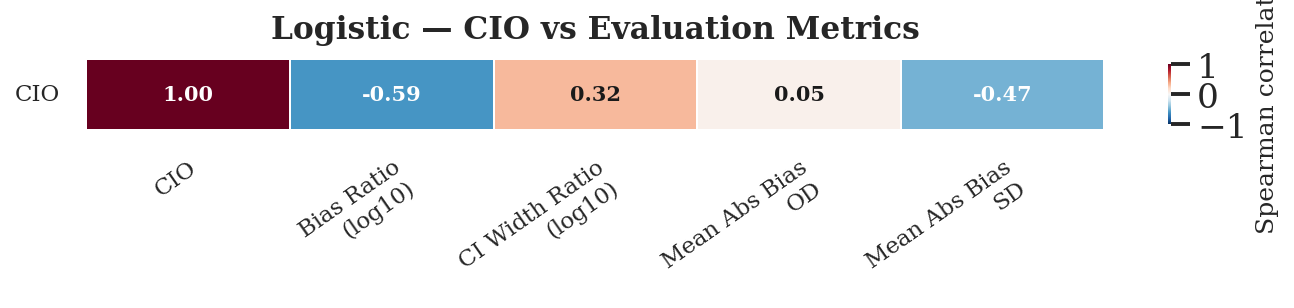

Saved -> ../results/logistic_report_figures/logistic_cio_vs_metrics_correlation_spearman.png


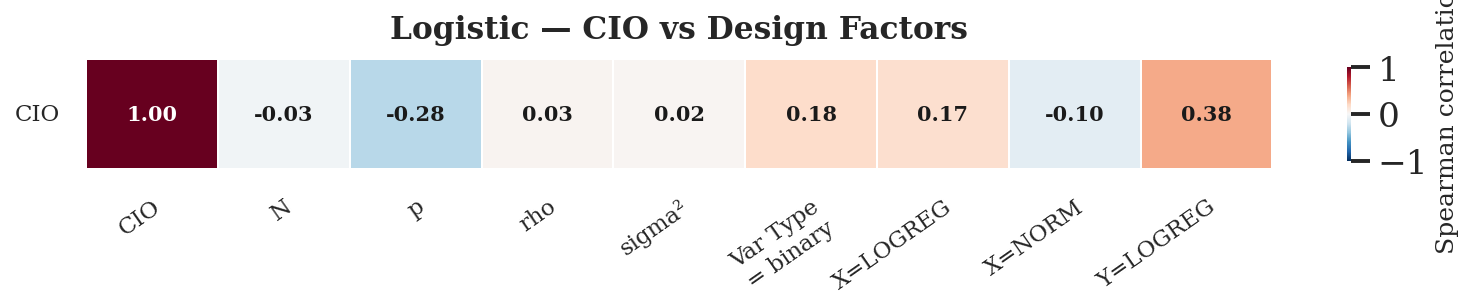

Saved -> ../results/logistic_report_figures/logistic_cio_vs_design_correlation_spearman.png


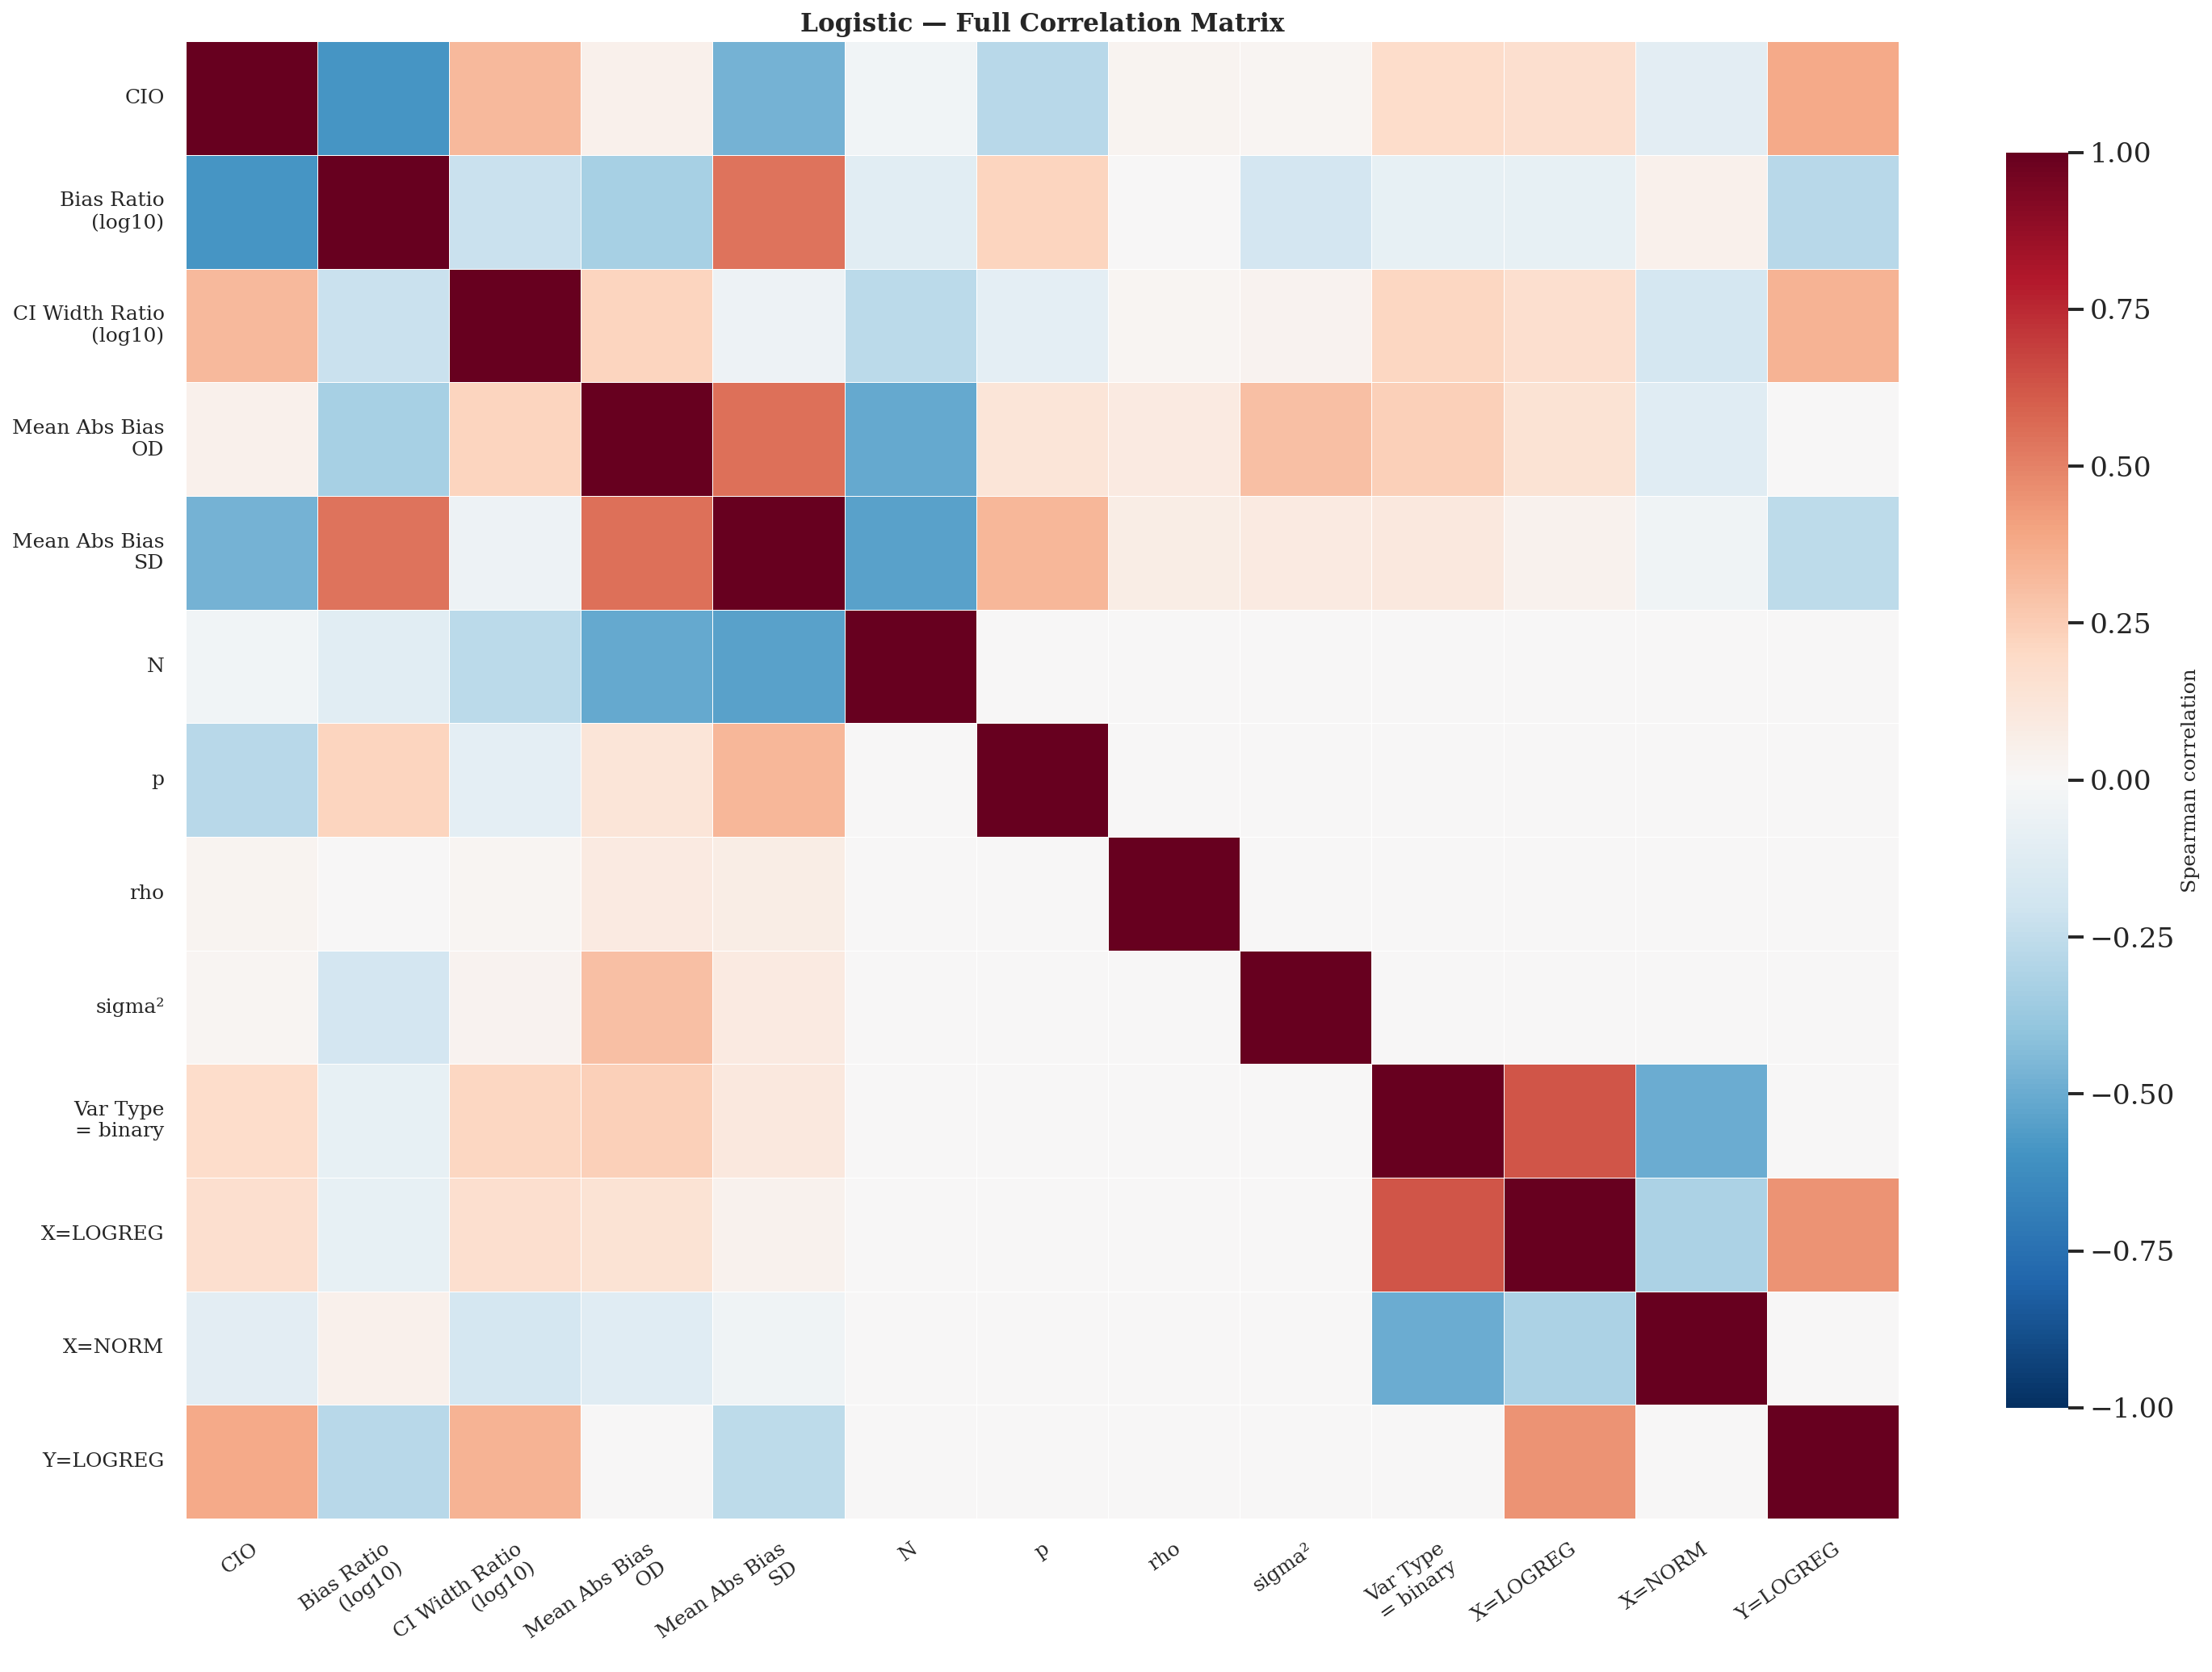

Saved -> ../results/logistic_report_figures/logistic_full_correlation_matrix_spearman.png


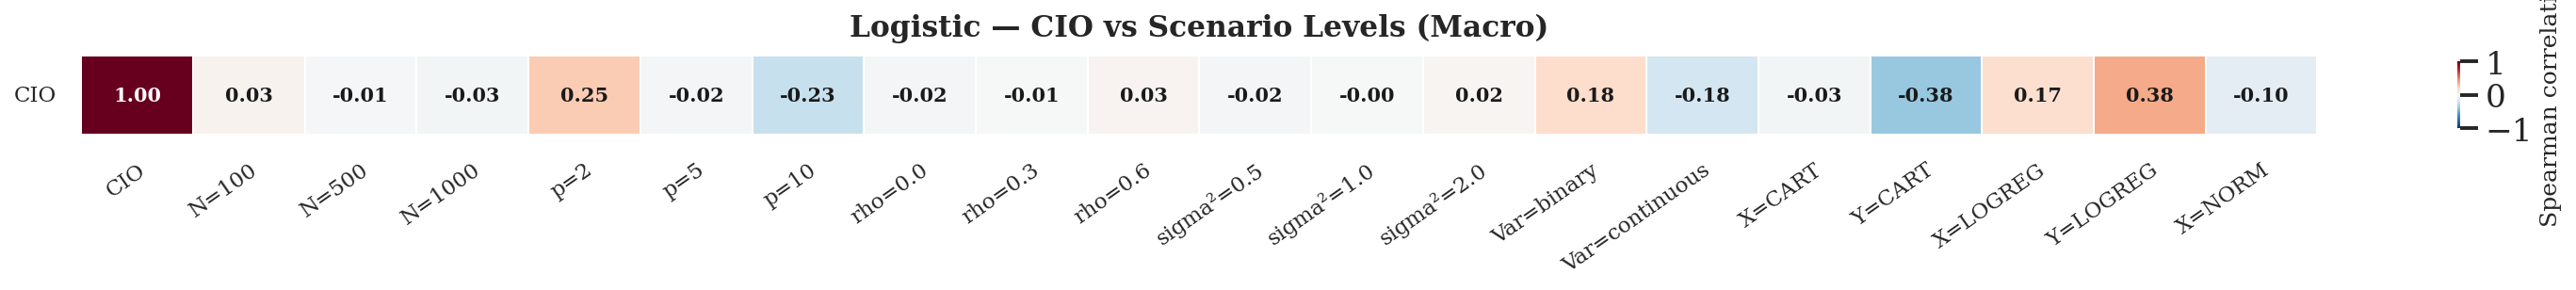

Saved -> ../results/logistic_report_figures/logistic_cio_vs_macro_levels_correlation_spearman.png


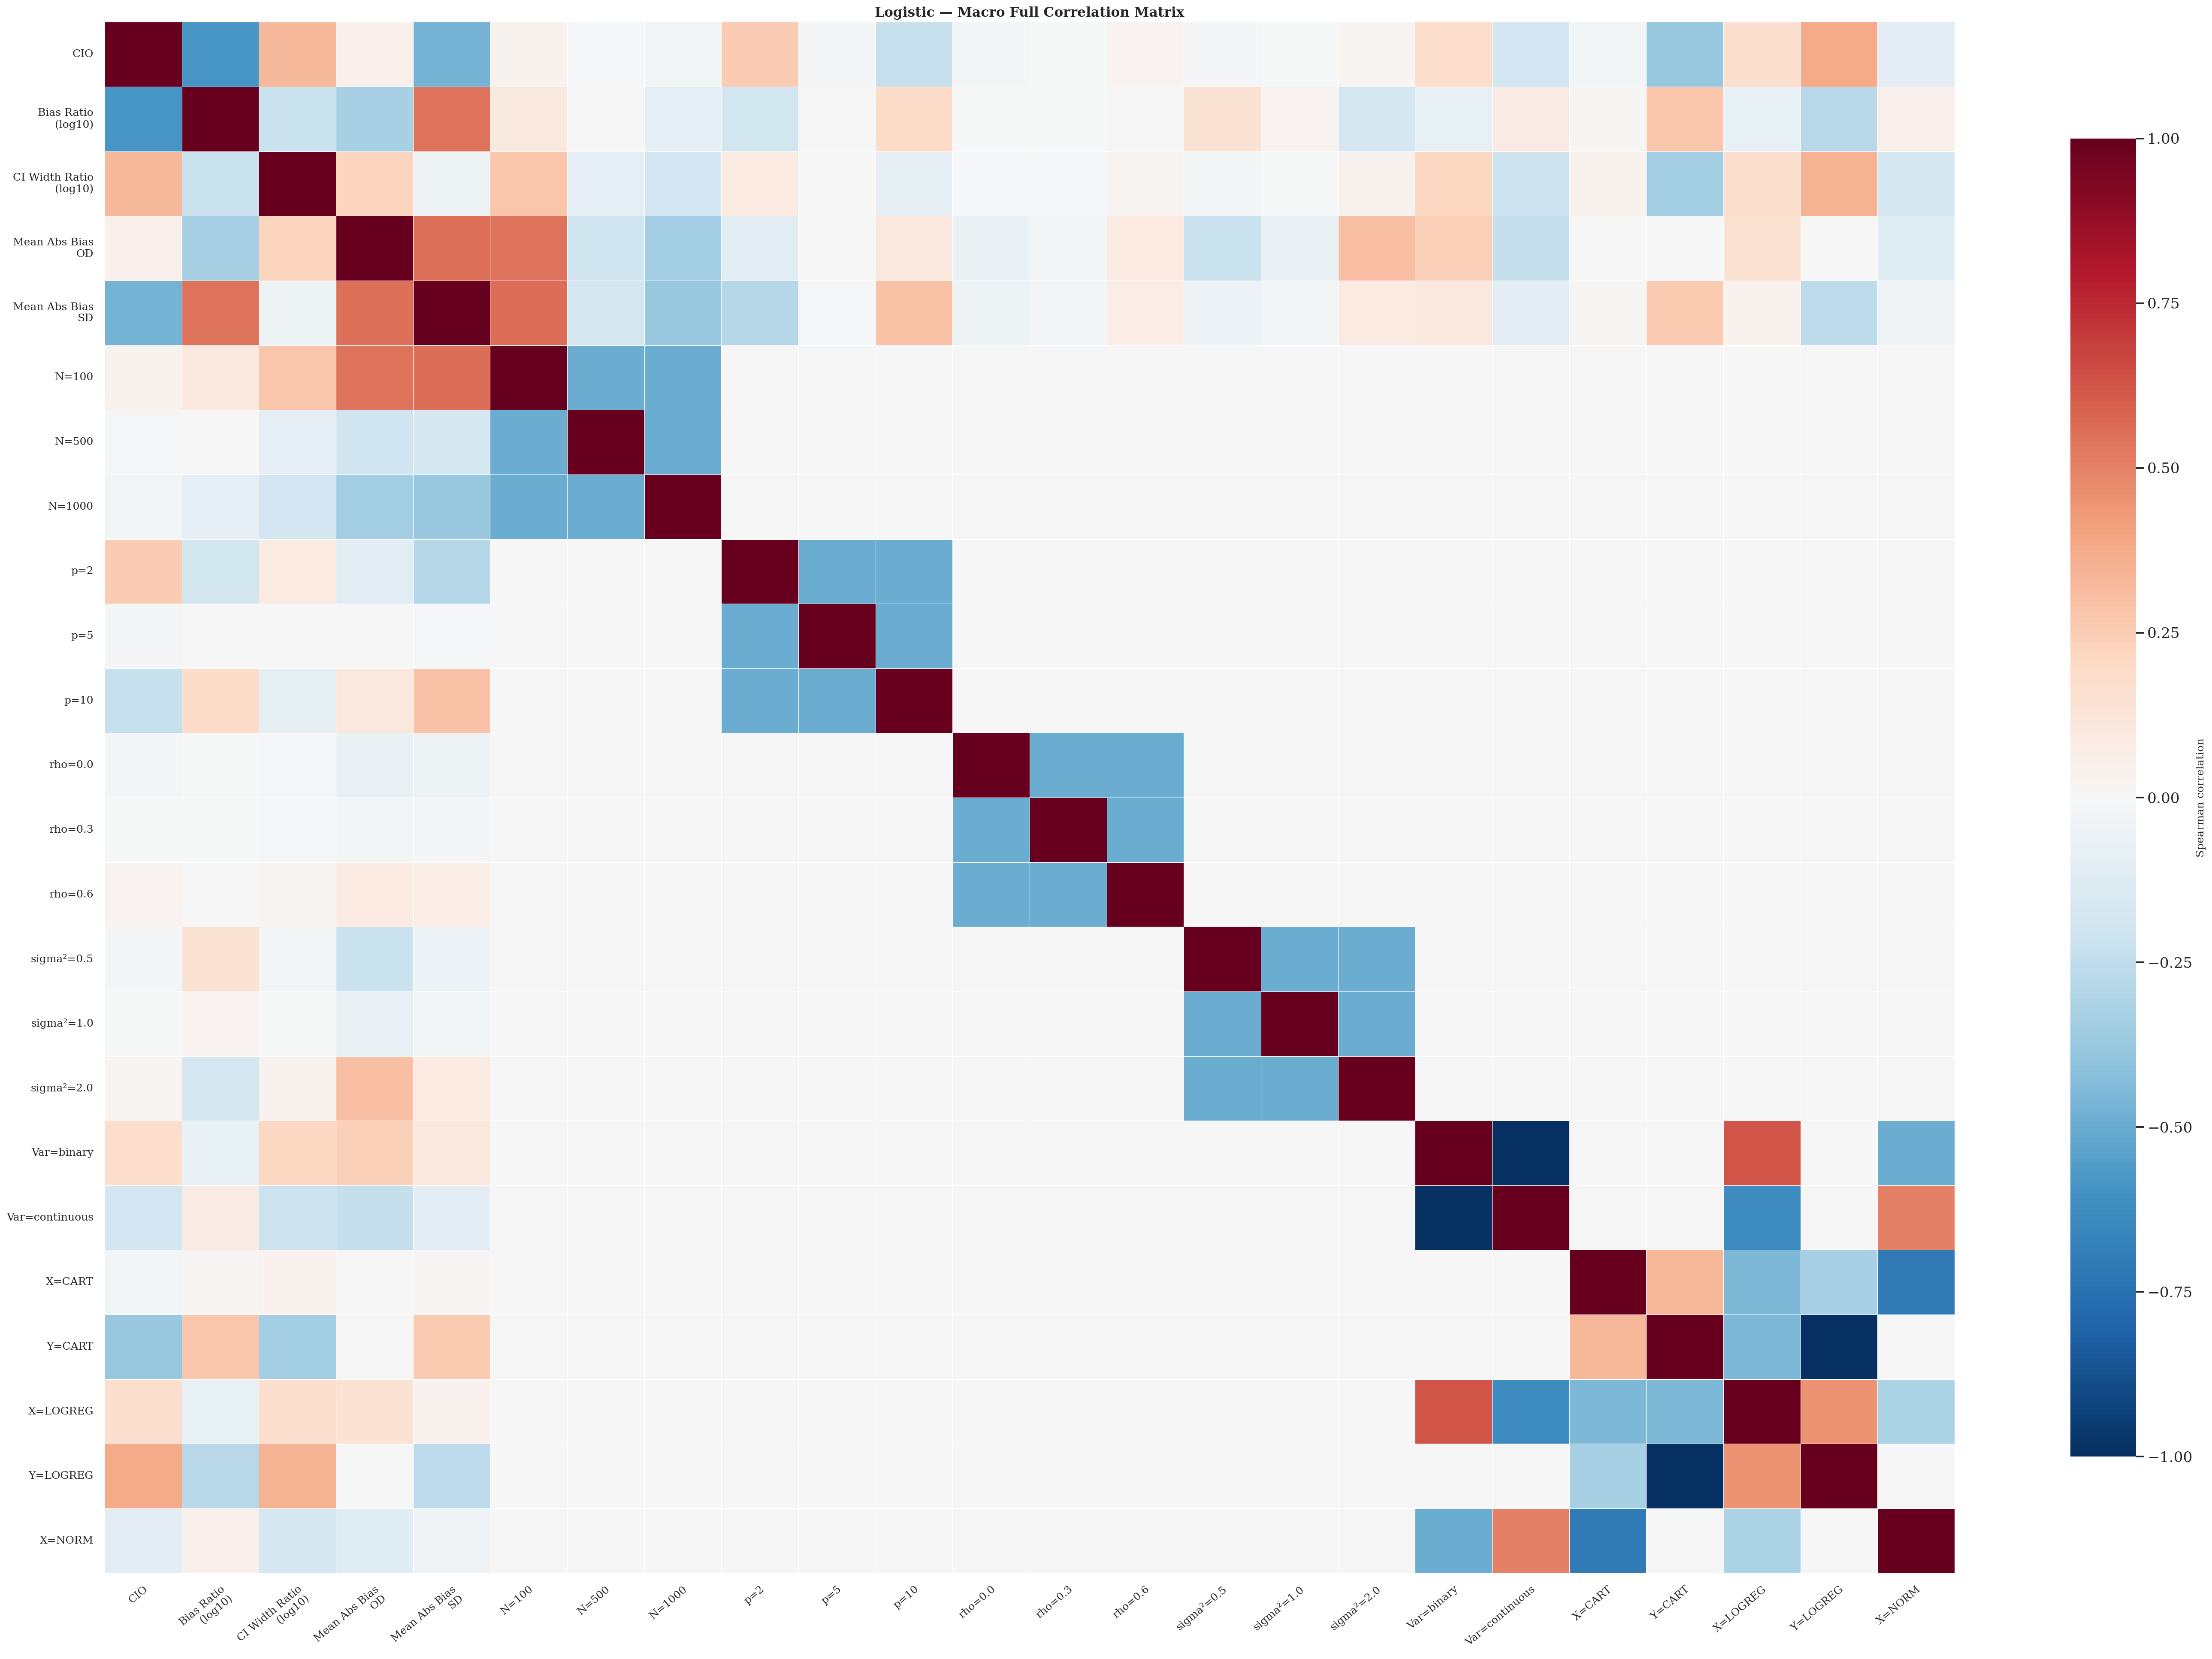

Saved -> ../results/logistic_report_figures/logistic_macro_full_correlation_matrix_spearman.png


In [5]:
# ── Plot helpers & palettes ──────────────────────────────────────────────────
VAR_TYPE_PALETTE = {"binary": "#2A9D8F", "continuous": "#E76F51"}
ARM_ORDER = sorted(df["arm"].dropna().unique())
ARM_PALETTE = dict(zip(ARM_ORDER, sns.color_palette("Set2", n_colors=len(ARM_ORDER))))

FACTOR_SPECS = [
    ("var_type", "Variable Type", VAR_TYPES),
    ("N", "Sample Size (N)", N_VALS),
    ("p", "Number of Predictors (p)", P_VALS),
    ("rho", "Correlation (rho)", RHO_VALS),
    ("sigma_2", "Error Variance (sigma²)", SIGMA2_VALS),
    ("arm", "Synthesis Arm", ARM_ORDER),
]

CROSS_FACTOR_SPECS = [
    ("var_type", "Variable Type", VAR_TYPES),
    ("N", "Sample Size (N)", N_VALS),
    ("p", "Number of Predictors (p)", P_VALS),
    ("rho", "Correlation (rho)", RHO_VALS),
    ("sigma_2", "Error Variance (sigma²)", SIGMA2_VALS),
]

def _as_cat(values):
    return values.astype(str) if values.dtype.kind in "if" else values.astype(str)

def _palette_for(col, order):
    if col == "var_type":
        return {str(k): VAR_TYPE_PALETTE[k] for k in order}
    if col == "arm":
        return {str(k): ARM_PALETTE[k] for k in order}
    if col == "N":
        return dict(zip([str(v) for v in order], sns.color_palette("crest", len(order))))
    if col == "p":
        return dict(zip([str(v) for v in order], sns.color_palette("flare", len(order))))
    if col == "rho":
        return dict(zip([str(v) for v in order], sns.color_palette("viridis", len(order))))
    if col == "sigma_2":
        return dict(zip([str(v) for v in order], sns.color_palette("magma", len(order))))
    return None

def _add_reference_line(ax, metric_col):
    if metric_col in {"bias_ratio", "ci_width_ratio"}:
        ax.axhline(1.0, color="black", lw=1.3, ls="--", alpha=0.7, zorder=2)

def _apply_metric_axis(ax, metric_col):
    if metric_col in {"bias_ratio", "ci_width_ratio"}:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2g}" if y > 0 else ""))

def make_univariate_distribution_grid(data, metric_col, metric_label, file_stub):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), squeeze=False)
    axes = axes.flatten()
    for ax, (col, label, order) in zip(axes, FACTOR_SPECS):
        plot_df = data[[metric_col, col]].dropna().copy()
        if plot_df.empty:
            ax.set_visible(False)
            continue
        plot_df[col] = _as_cat(plot_df[col])
        order_str = [str(v) for v in order]
        palette = _palette_for(col, order)

        sns.boxplot(
            data=plot_df, x=col, y=metric_col,
            order=order_str, palette=palette, ax=ax, width=0.6,
            showfliers=False, linewidth=1.2,
            boxprops={"alpha": 0.95},
            whiskerprops={"linewidth": 1.2},
            medianprops={"color": "#111111", "linewidth": 1.8},
        )

        _add_reference_line(ax, metric_col)
        _apply_metric_axis(ax, metric_col)
        ax.set_title(label)
        ax.set_xlabel("")
        ax.set_ylabel(metric_label)
        if col == "arm":
            ax.tick_params(axis="x", rotation=45)
        else:
            ax.tick_params(axis="x", rotation=0)

    fig.suptitle(f"{TARGET_LABEL} — {metric_label}: Univariate Distributions", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    out = os.path.join(fig_dir, f"{TARGET_REG}_{file_stub}_univariate.png")
    fig.savefig(out)
    plt.show()
    print(f"Saved -> {out}")

def make_method_cross_grid(data, metric_col, metric_label, file_stub):
    fig, axes = plt.subplots(3, 2, figsize=(20, 14), squeeze=False)
    axes = axes.flatten()
    for ax, (col, label, order) in zip(axes, CROSS_FACTOR_SPECS):
        plot_df = data[[metric_col, "arm", col]].dropna().copy()
        if plot_df.empty:
            ax.set_visible(False)
            continue

        plot_df["arm"] = plot_df["arm"].astype(str)
        plot_df[col] = _as_cat(plot_df[col])
        hue_order = [str(v) for v in order]
        palette = _palette_for(col, order)

        sns.boxplot(
            data=plot_df, x="arm", y=metric_col, hue=col,
            order=ARM_ORDER, hue_order=hue_order, palette=palette,
            ax=ax, linewidth=1.1, saturation=0.95,
            showfliers=False
        )

        _add_reference_line(ax, metric_col)
        _apply_metric_axis(ax, metric_col)
        ax.set_title(f"Arm × {label}")
        ax.set_xlabel("Synthesis Arm")
        ax.set_ylabel(metric_label)
        ax.tick_params(axis="x", rotation=45)
        ax.legend(title=label, fontsize=8, title_fontsize=9, frameon=True, ncols=1)

    for ax in axes[len(CROSS_FACTOR_SPECS):]:
        ax.set_visible(False)

    fig.suptitle(f"{TARGET_LABEL} — {metric_label}: Cross-Analysis by Method", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    out = os.path.join(fig_dir, f"{TARGET_REG}_{file_stub}_by_method.png")
    fig.savefig(out)
    plt.show()
    print(f"Saved -> {out}")

def _safe_token(value):
    return str(value).replace(".", "p")

def _metric_and_factor_frame(data):
    corr_df = pd.DataFrame(index=data.index)

    metric_spec = [
        ("ci_overlap_pct", "CIO"),
        ("log10_bias_ratio", "Bias Ratio\n(log10)"),
        ("log10_ci_width_ratio", "CI Width Ratio\n(log10)"),
        ("mean_abs_bias_od", "Mean Abs Bias\nOD"),
        ("mean_abs_bias_sd", "Mean Abs Bias\nSD"),
    ]
    metric_labels = {col: label for col, label in metric_spec if col in data.columns}
    metric_cols = [col for col, _ in metric_spec if col in data.columns]

    for col in metric_cols:
        corr_df[col] = data[col].astype(float)

    factor_labels = {
        "N": "N",
        "p": "p",
        "rho": "rho",
        "sigma_2": "sigma²",
        "is_binary_var_type": "Var Type\n= binary",
    }
    for col in ["N", "p", "rho", "sigma_2"]:
        corr_df[col] = data[col].astype(float)

    corr_df["is_binary_var_type"] = (data["var_type"].astype(str) == "binary").astype(float)

    for method_col, prefix in [("x_method", "X"), ("y_method", "Y")]:
        levels = sorted(data[method_col].dropna().astype(str).unique())
        for level in levels[1:]:
            dummy_col = f"{method_col}_{level}"
            corr_df[dummy_col] = (data[method_col].astype(str) == level).astype(float)
            factor_labels[dummy_col] = f"{prefix}={level}"

    factor_cols = [col for col in corr_df.columns if col not in metric_cols]
    return corr_df, metric_cols, factor_cols, metric_labels, factor_labels

def _draw_corr_heatmap(matrix, title, out_name, cbar_label):
    fig_w = max(9.5, 0.9 * len(matrix.columns) + 2.8)
    fig_h = max(2.4, 1.15 * len(matrix.index) + 1.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    sns.heatmap(
        matrix,
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 10, "fontweight": "bold"},
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"shrink": 0.85, "label": cbar_label},
        ax=ax,
    )
    values = matrix.to_numpy(dtype=float).ravel()
    for text, value in zip(ax.texts, values):
        text.set_color("white" if abs(value) >= 0.45 else "#1a1a1a")

    ax.set_title(title, fontsize=15, fontweight="bold", pad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", rotation_mode="anchor", fontsize=11)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
    plt.tight_layout()

    out = os.path.join(fig_dir, out_name)
    fig.savefig(out)
    plt.show()
    print(f"Saved -> {out}")
    return fig, ax

def plot_metric_design_correlation(data, method="spearman", show_full_matrix=False):
    corr_df, metric_cols, factor_cols, metric_labels, factor_labels = _metric_and_factor_frame(data)
    corr_cols = metric_cols + factor_cols
    corr_matrix = corr_df[corr_cols].corr(method=method)

    cio_col = "ci_overlap_pct"
    metric_view = corr_matrix.loc[[cio_col], metric_cols].copy()
    design_view = corr_matrix.loc[[cio_col], [cio_col] + factor_cols].copy()

    metric_view.index = [metric_labels.get(col, col) for col in metric_view.index]
    metric_view.columns = [metric_labels.get(col, factor_labels.get(col, col)) for col in metric_view.columns]
    design_view.index = [metric_labels.get(col, col) for col in design_view.index]
    design_view.columns = [metric_labels.get(col, factor_labels.get(col, col)) for col in design_view.columns]

    _draw_corr_heatmap(
        metric_view,
        f"{TARGET_LABEL} — CIO vs Evaluation Metrics",
        f"{TARGET_REG}_cio_vs_metrics_correlation_{_safe_token(method)}.png",
        f"{method.title()} correlation",
    )
    _draw_corr_heatmap(
        design_view,
        f"{TARGET_LABEL} — CIO vs Design Factors",
        f"{TARGET_REG}_cio_vs_design_correlation_{_safe_token(method)}.png",
        f"{method.title()} correlation",
    )

    full = corr_matrix.copy()
    full.index = [metric_labels.get(col, factor_labels.get(col, col)) for col in full.index]
    full.columns = [metric_labels.get(col, factor_labels.get(col, col)) for col in full.columns]

    if show_full_matrix:
        full_w = max(17, 1.05 * len(full.columns) + 6)
        full_h = max(10, 0.78 * len(full.index) + 4)
        fig_full, ax_full = plt.subplots(figsize=(full_w, full_h))
        sns.heatmap(
            full,
            cmap="RdBu_r",
            center=0,
            vmin=-1,
            vmax=1,
            annot=False,
            linewidths=0.4,
            linecolor="white",
            cbar_kws={"shrink": 0.85, "label": f"{method.title()} correlation"},
            ax=ax_full,
        )
        ax_full.set_title(f"{TARGET_LABEL} — Full Correlation Matrix", fontsize=15, fontweight="bold")
        ax_full.set_xticklabels(
            ax_full.get_xticklabels(),
            rotation=35,
            ha="right",
            rotation_mode="anchor",
            fontsize=12,
        )
        ax_full.set_yticklabels(ax_full.get_yticklabels(), rotation=0, fontsize=12)
        plt.tight_layout()

        out_full = os.path.join(fig_dir, f"{TARGET_REG}_full_correlation_matrix_{_safe_token(method)}.png")
        fig_full.savefig(out_full)
        plt.show()
        print(f"Saved -> {out_full}")

    return metric_view, design_view, full

def _macro_level_frame(data):
    macro_df = pd.DataFrame(index=data.index)

    metric_spec = [
        ("ci_overlap_pct", "CIO"),
        ("log10_bias_ratio", "Bias Ratio\n(log10)"),
        ("log10_ci_width_ratio", "CI Width Ratio\n(log10)"),
        ("mean_abs_bias_od", "Mean Abs Bias\nOD"),
        ("mean_abs_bias_sd", "Mean Abs Bias\nSD"),
    ]
    macro_labels = {col: label for col, label in metric_spec if col in data.columns}
    metric_cols = [col for col, _ in metric_spec if col in data.columns]
    for col in metric_cols:
        macro_df[col] = data[col].astype(float)

    for n_val in N_VALS:
        col = f"N__{n_val}"
        macro_df[col] = (data["N"].astype(float) == float(n_val)).astype(float)
        macro_labels[col] = f"N={n_val}"

    for p_val in P_VALS:
        col = f"p__{p_val}"
        macro_df[col] = (data["p"].astype(float) == float(p_val)).astype(float)
        macro_labels[col] = f"p={p_val}"

    for rho_val in RHO_VALS:
        col = f"rho__{rho_val}"
        macro_df[col] = np.isclose(data["rho"].astype(float), float(rho_val)).astype(float)
        macro_labels[col] = f"rho={rho_val}"

    for sigma_val in SIGMA2_VALS:
        col = f"sigma_2__{sigma_val}"
        macro_df[col] = np.isclose(data["sigma_2"].astype(float), float(sigma_val)).astype(float)
        macro_labels[col] = f"sigma²={sigma_val}"

    for vt in VAR_TYPES:
        col = f"var_type__{vt}"
        macro_df[col] = (data["var_type"].astype(str) == vt).astype(float)
        macro_labels[col] = f"Var={vt}"

    method_levels = sorted({m.upper() for m in CONT_METHODS + BIN_METHODS})
    for level in method_levels:
        x_col = f"x_method__{level}"
        y_col = f"y_method__{level}"
        macro_df[x_col] = (data["x_method"].astype(str) == level).astype(float)
        macro_df[y_col] = (data["y_method"].astype(str) == level).astype(float)
        macro_labels[x_col] = f"X={level}"
        macro_labels[y_col] = f"Y={level}"

    keep_cols = [col for col in macro_df.columns if macro_df[col].nunique(dropna=True) > 1]
    macro_df = macro_df[keep_cols]
    level_cols = [col for col in macro_df.columns if col not in metric_cols]
    return macro_df, metric_cols, level_cols, macro_labels

def plot_macro_scenario_correlation(data, method="spearman", show_full_matrix=True):
    macro_df, metric_cols, level_cols, macro_labels = _macro_level_frame(data)
    corr_cols = metric_cols + level_cols
    corr_matrix = macro_df[corr_cols].corr(method=method)

    cio_col = "ci_overlap_pct"
    cio_macro = corr_matrix.loc[[cio_col], [cio_col] + level_cols].copy()
    cio_macro.index = [macro_labels.get(col, col) for col in cio_macro.index]
    cio_macro.columns = [macro_labels.get(col, col) for col in cio_macro.columns]

    _draw_corr_heatmap(
        cio_macro,
        f"{TARGET_LABEL} — CIO vs Scenario Levels (Macro)",
        f"{TARGET_REG}_cio_vs_macro_levels_correlation_{_safe_token(method)}.png",
        f"{method.title()} correlation",
    )

    macro_full = corr_matrix.copy()
    macro_full.index = [macro_labels.get(col, col) for col in macro_full.index]
    macro_full.columns = [macro_labels.get(col, col) for col in macro_full.columns]

    if show_full_matrix:
        full_w = max(24, 1.25 * len(macro_full.columns) + 8)
        full_h = max(12, 0.88 * len(macro_full.index) + 5)
        fig_full, ax_full = plt.subplots(figsize=(full_w, full_h))
        sns.heatmap(
            macro_full,
            cmap="RdBu_r",
            center=0,
            vmin=-1,
            vmax=1,
            annot=False,
            linewidths=0.35,
            linecolor="white",
            cbar_kws={"shrink": 0.85, "label": f"{method.title()} correlation"},
            ax=ax_full,
        )
        ax_full.set_title(f"{TARGET_LABEL} — Macro Full Correlation Matrix", fontsize=15, fontweight="bold")
        ax_full.set_xticklabels(
            ax_full.get_xticklabels(),
            rotation=40,
            ha="right",
            rotation_mode="anchor",
            fontsize=12,
        )
        ax_full.set_yticklabels(ax_full.get_yticklabels(), rotation=0, fontsize=12)
        plt.tight_layout()

        out_full = os.path.join(fig_dir, f"{TARGET_REG}_macro_full_correlation_matrix_{_safe_token(method)}.png")
        fig_full.savefig(out_full)
        plt.show()
        print(f"Saved -> {out_full}")

    return cio_macro, macro_full

corr_metrics, corr_design, corr_full = plot_metric_design_correlation(
    df,
    method=CORR_METHOD,
    show_full_matrix=CORR_SHOW_FULL_MATRIX,
)
corr_macro_cio, corr_macro_full = plot_macro_scenario_correlation(
    df,
    method=CORR_METHOD,
    show_full_matrix=CORR_SHOW_FULL_MATRIX,
)

## CIO Correlation Ranking

This table ranks the strongest and weakest associations with **CIO** from the
full correlation matrix shown above. The CIO self-correlation is excluded.

In [6]:
def summarize_cio_correlations(corr_matrix, top_n=10, anchor="CIO"):
    cio_corr = (
        corr_matrix.loc[anchor]
        .drop(labels=[anchor], errors="ignore")
        .dropna()
        .sort_values(ascending=False)
    )

    highest = cio_corr.head(top_n).reset_index()
    highest.columns = ["Highest With CIO", "Correlation +"]

    lowest = cio_corr.sort_values(ascending=True).head(top_n).reset_index()
    lowest.columns = ["Lowest With CIO", "Correlation -"]

    max_len = max(len(highest), len(lowest))
    highest = highest.reindex(range(max_len))
    lowest = lowest.reindex(range(max_len))
    return pd.concat([highest, lowest], axis=1)

cio_corr_table = summarize_cio_correlations(corr_full, top_n=10, anchor="CIO")

print("Top 10 highest and lowest correlations with CIO")
display(
    cio_corr_table.style
        .format({
            "Correlation +": "{:.3f}",
            "Correlation -": "{:.3f}",
        })
        .background_gradient(subset=["Correlation +"], cmap="YlOrRd")
        .background_gradient(subset=["Correlation -"], cmap="Blues_r")
        .set_caption(f"{TARGET_LABEL} — Top 10 Highest and Lowest Correlations With CIO")
)

Top 10 highest and lowest correlations with CIO


,Highest With CIO,Correlation +,Lowest With CIO,Correlation -
0,Y=LOGREG,0.377,Bias Ratio (log10),-0.586
1,CI Width Ratio (log10),0.322,Mean Abs Bias SD,-0.474
2,Var Type = binary,0.185,p,-0.278
3,X=LOGREG,0.171,X=NORM,-0.104
4,Mean Abs Bias OD,0.048,N,-0.034
5,rho,0.027,sigma²,0.020
6,sigma²,0.020,rho,0.027
7,N,-0.034,Mean Abs Bias OD,0.048
8,X=NORM,-0.104,X=LOGREG,0.171
9,p,-0.278,Var Type = binary,0.185


## Exploratory Structure: PCA and t-SNE

Before moving into factor-wise summaries, this section looks for broad latent patterns in the three main indicators plus the OD/SD absolute bias components.

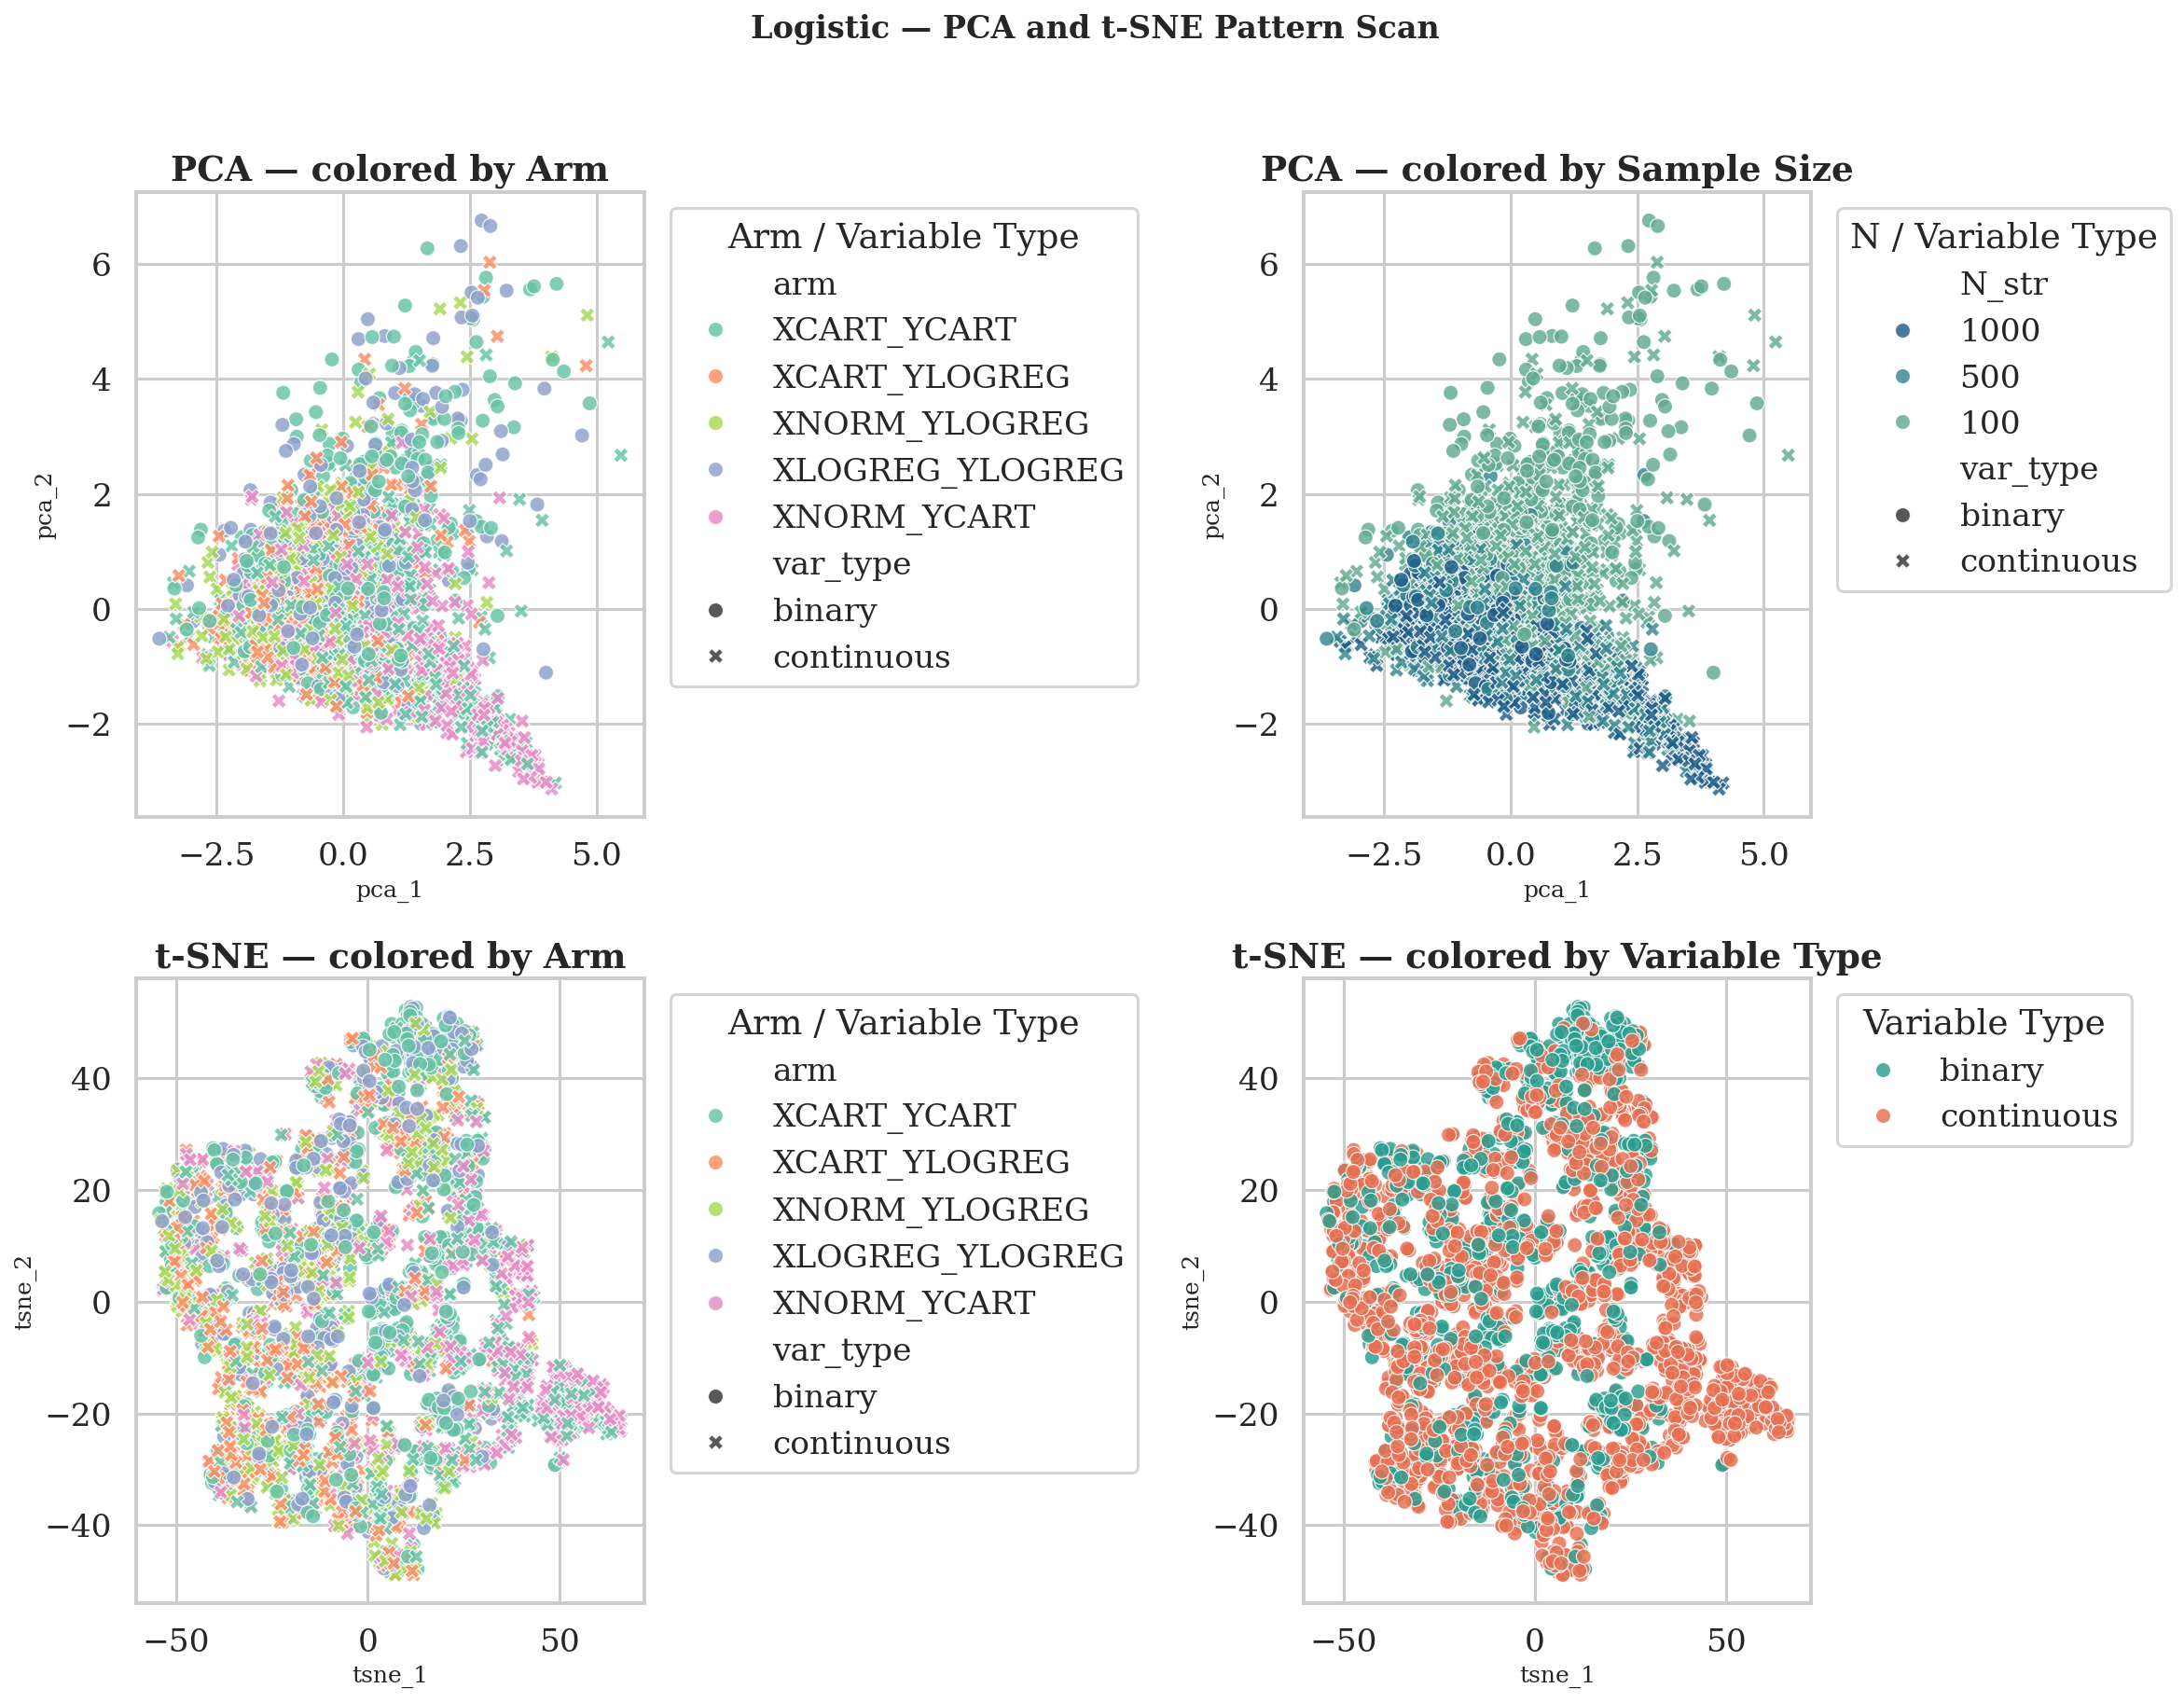

Saved -> ../results/logistic_report_figures/logistic_pattern_scan_pca_tsne.png
Explained variance ratio (PCA): [0.396 0.343]
t-SNE perplexity used: 35


In [7]:
# ── PCA + t-SNE ───────────────────────────────────────────────────────────────
EMBED_FEATURES = [
    "ci_overlap_pct",
    "log10_bias_ratio",
    "log10_ci_width_ratio",
    "mean_abs_bias_od",
    "mean_abs_bias_sd",
]

embed_df = df[["arm", "var_type", "N", "p", "rho", "sigma_2"] + EMBED_FEATURES].dropna().copy()
embed_df = embed_df.sample(n=min(len(embed_df), 3000), random_state=42).reset_index(drop=True)

if len(embed_df) < 10:
    print("Not enough complete rows for PCA/t-SNE after dropping NaNs.")
else:
    X_embed = embed_df[EMBED_FEATURES].copy()
    for col in EMBED_FEATURES:
        lo, hi = X_embed[col].quantile([0.005, 0.995])
        X_embed[col] = X_embed[col].clip(lo, hi)

    X = StandardScaler().fit_transform(X_embed)
    pca = PCA(n_components=2, random_state=42)
    pca_xy = pca.fit_transform(X)

    perplexity = min(35, max(8, len(embed_df) // 20))
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=42,
    )
    tsne_xy = tsne.fit_transform(X)

    embed_df["pca_1"] = pca_xy[:, 0]
    embed_df["pca_2"] = pca_xy[:, 1]
    embed_df["tsne_1"] = tsne_xy[:, 0]
    embed_df["tsne_2"] = tsne_xy[:, 1]

    n_palette = dict(zip([str(v) for v in N_VALS], sns.color_palette("crest", len(N_VALS))))

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    sns.scatterplot(
        data=embed_df, x="pca_1", y="pca_2",
        hue="arm", palette=ARM_PALETTE, style="var_type",
        alpha=0.82, s=60, ax=axes[0, 0]
    )
    axes[0, 0].set_title("PCA — colored by Arm")
    axes[0, 0].legend(title="Arm / Variable Type", bbox_to_anchor=(1.02, 1), loc="upper left")

    sns.scatterplot(
        data=embed_df.assign(N_str=embed_df["N"].astype(str)), x="pca_1", y="pca_2",
        hue="N_str", palette=n_palette, style="var_type",
        alpha=0.82, s=60, ax=axes[0, 1]
    )
    axes[0, 1].set_title("PCA — colored by Sample Size")
    axes[0, 1].legend(title="N / Variable Type", bbox_to_anchor=(1.02, 1), loc="upper left")

    sns.scatterplot(
        data=embed_df, x="tsne_1", y="tsne_2",
        hue="arm", palette=ARM_PALETTE, style="var_type",
        alpha=0.82, s=60, ax=axes[1, 0]
    )
    axes[1, 0].set_title("t-SNE — colored by Arm")
    axes[1, 0].legend(title="Arm / Variable Type", bbox_to_anchor=(1.02, 1), loc="upper left")

    sns.scatterplot(
        data=embed_df, x="tsne_1", y="tsne_2",
        hue="var_type", palette=VAR_TYPE_PALETTE,
        alpha=0.82, s=60, ax=axes[1, 1]
    )
    axes[1, 1].set_title("t-SNE — colored by Variable Type")
    axes[1, 1].legend(title="Variable Type", bbox_to_anchor=(1.02, 1), loc="upper left")

    fig.suptitle(
        f"{TARGET_LABEL} — PCA and t-SNE Pattern Scan",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    out = os.path.join(fig_dir, f"{TARGET_REG}_pattern_scan_pca_tsne.png")
    fig.savefig(out)
    plt.show()
    print(f"Saved -> {out}")
    print("Explained variance ratio (PCA):", np.round(pca.explained_variance_ratio_, 3))
    print(f"t-SNE perplexity used: {perplexity}")

## Univariate Descriptive Analysis

Each figure isolates one factor at a time while mixing the remaining dimensions, matching the requested main-text simplification.

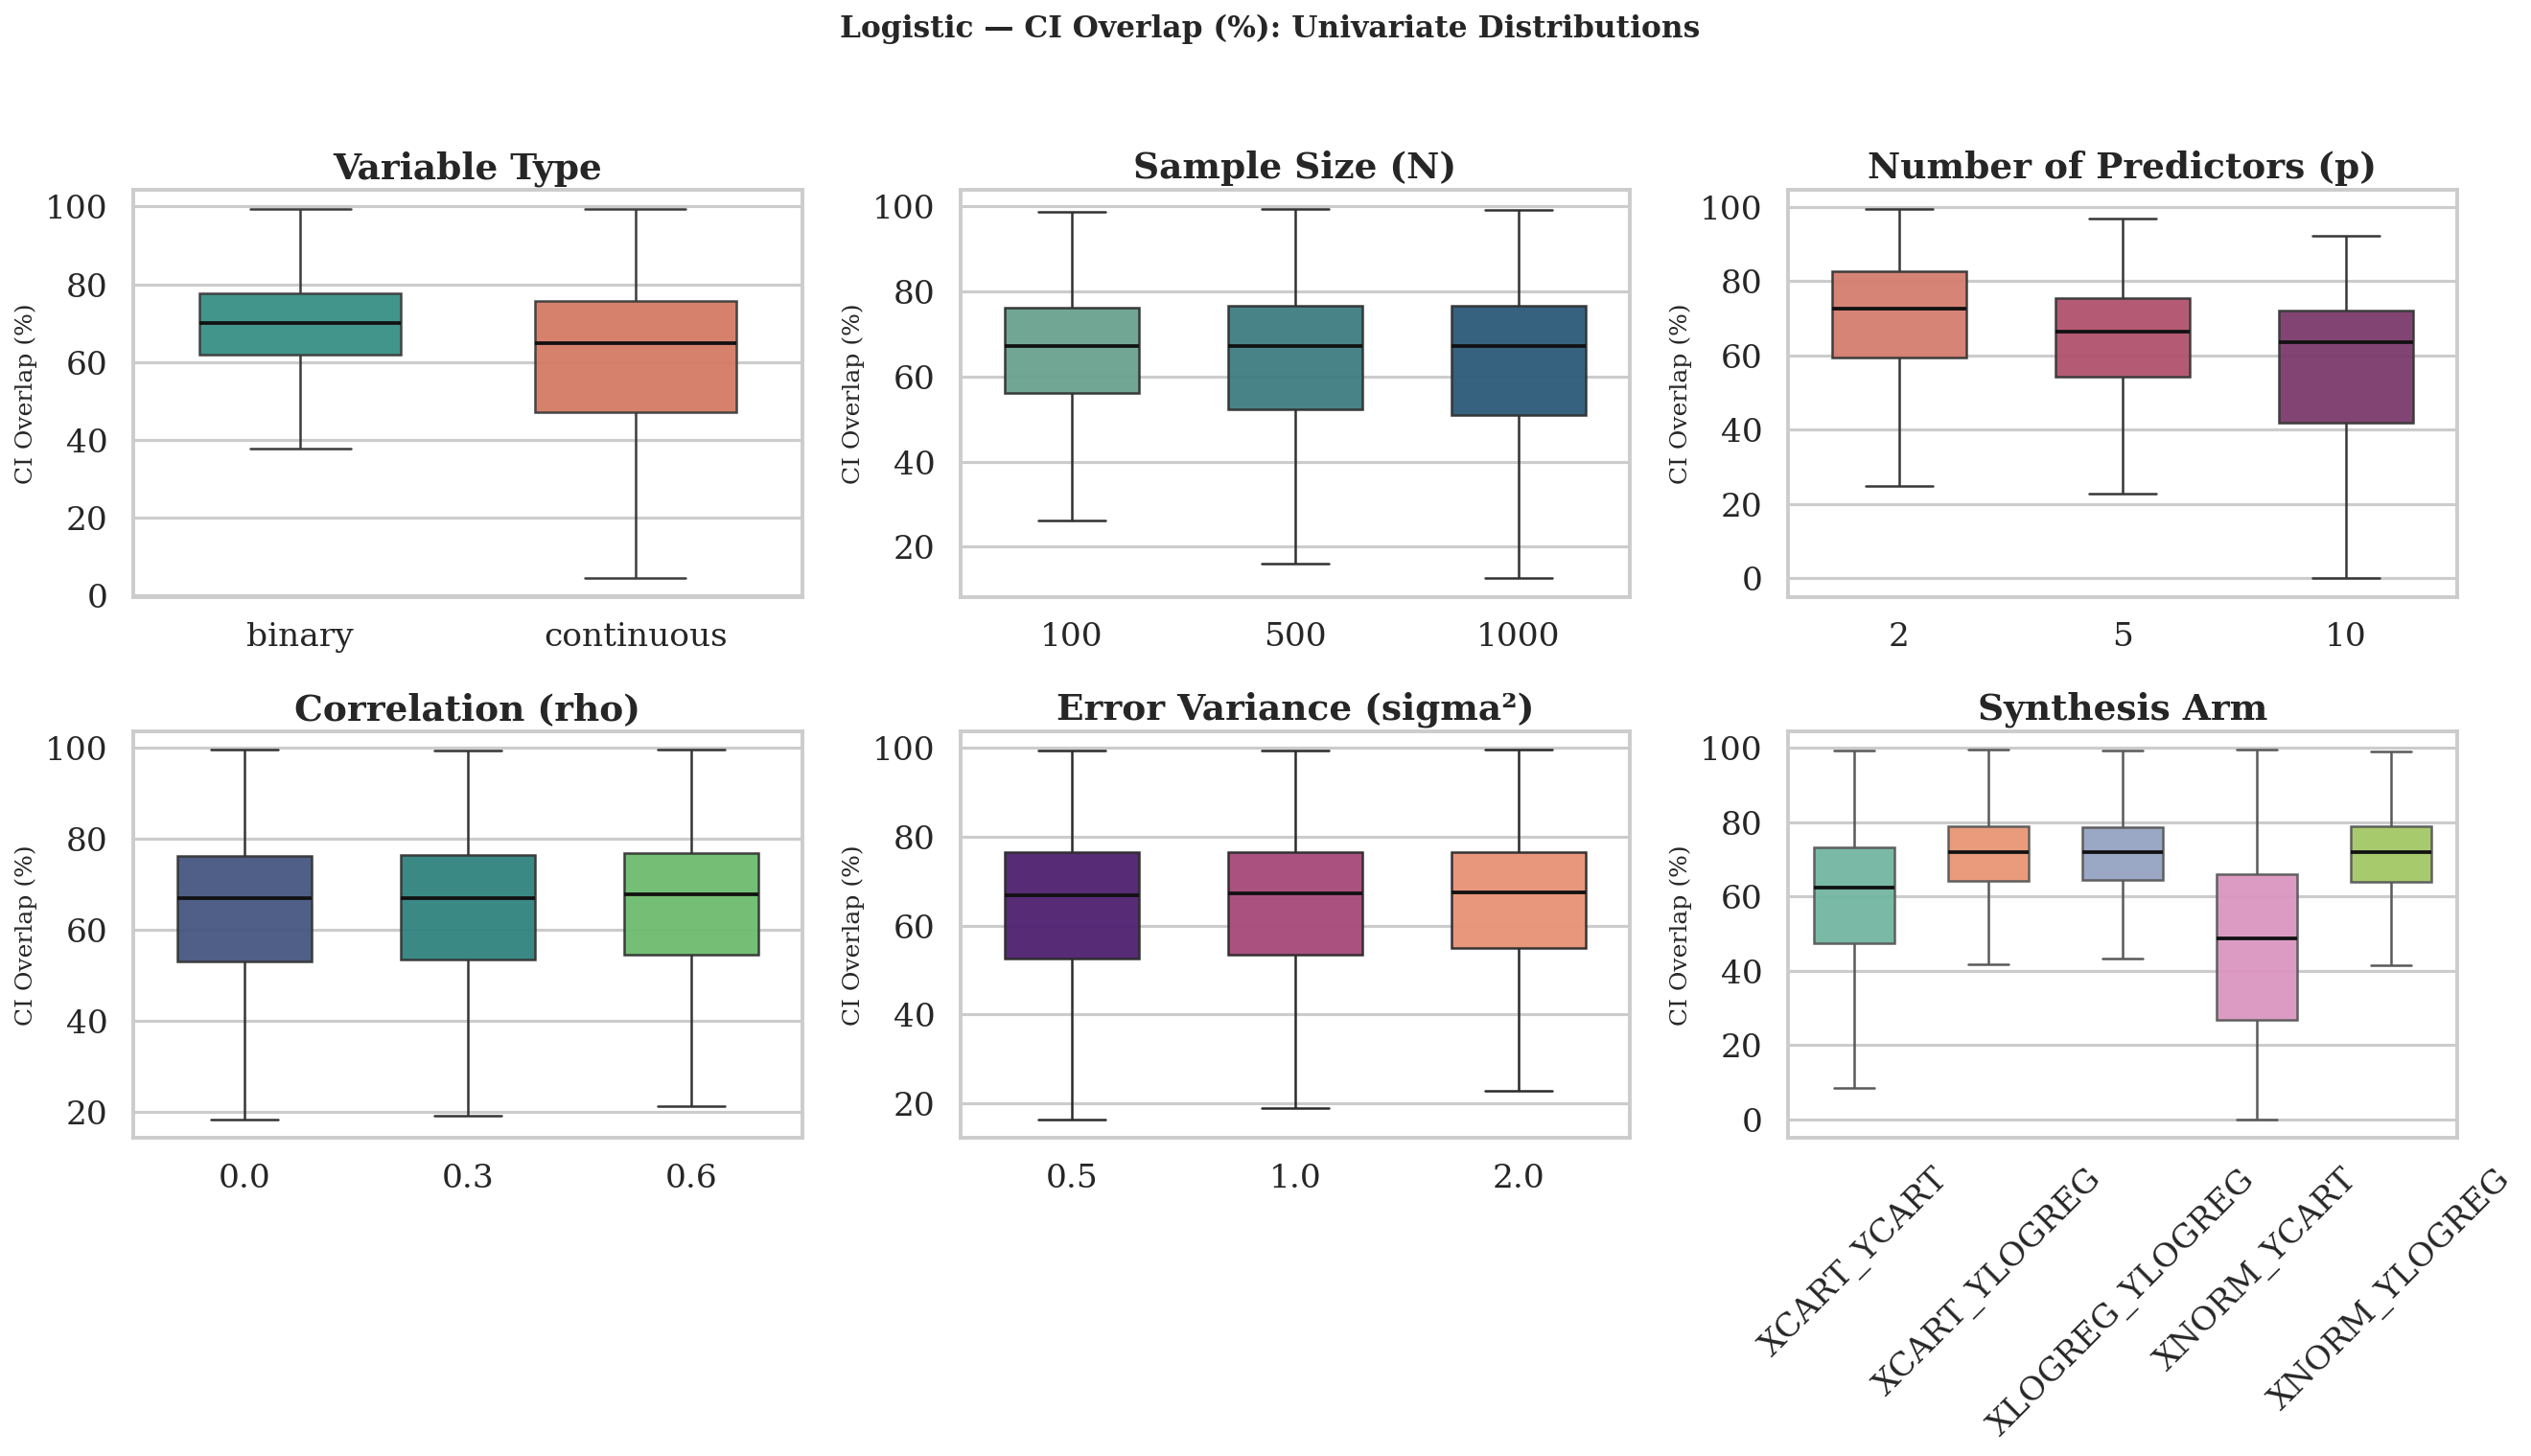

Saved -> ../results/logistic_report_figures/logistic_cio_univariate.png


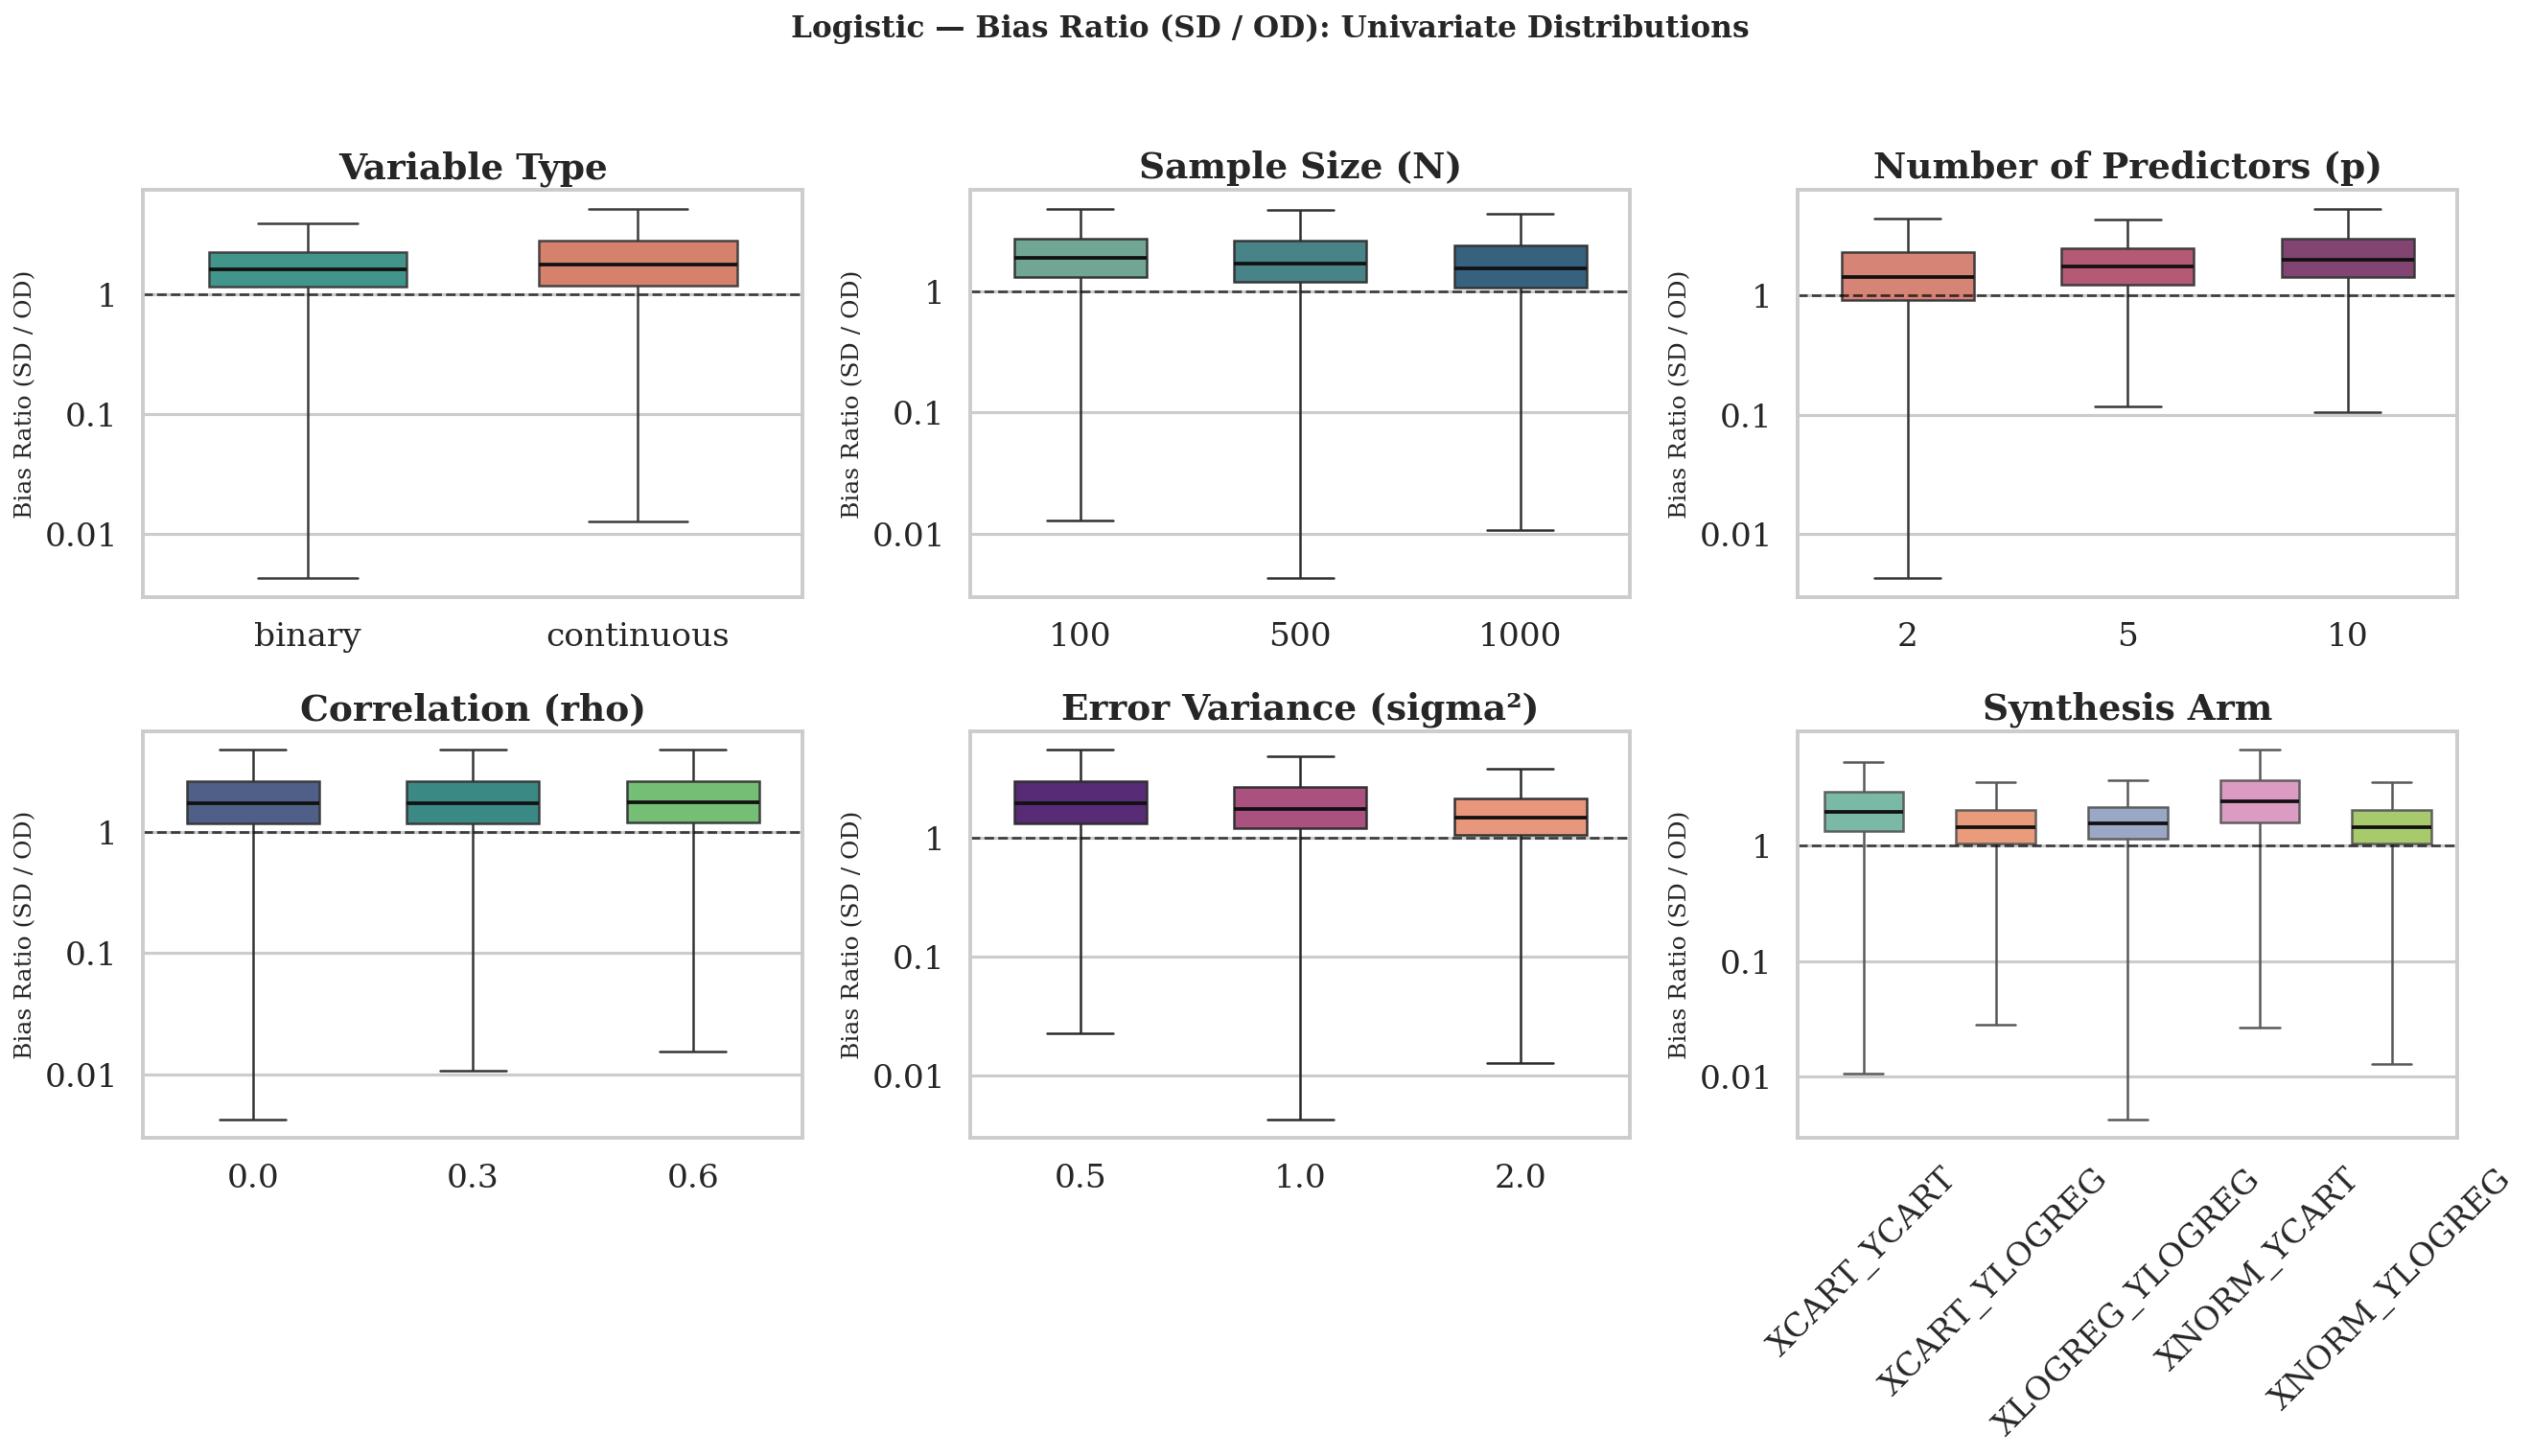

Saved -> ../results/logistic_report_figures/logistic_bias_ratio_univariate.png


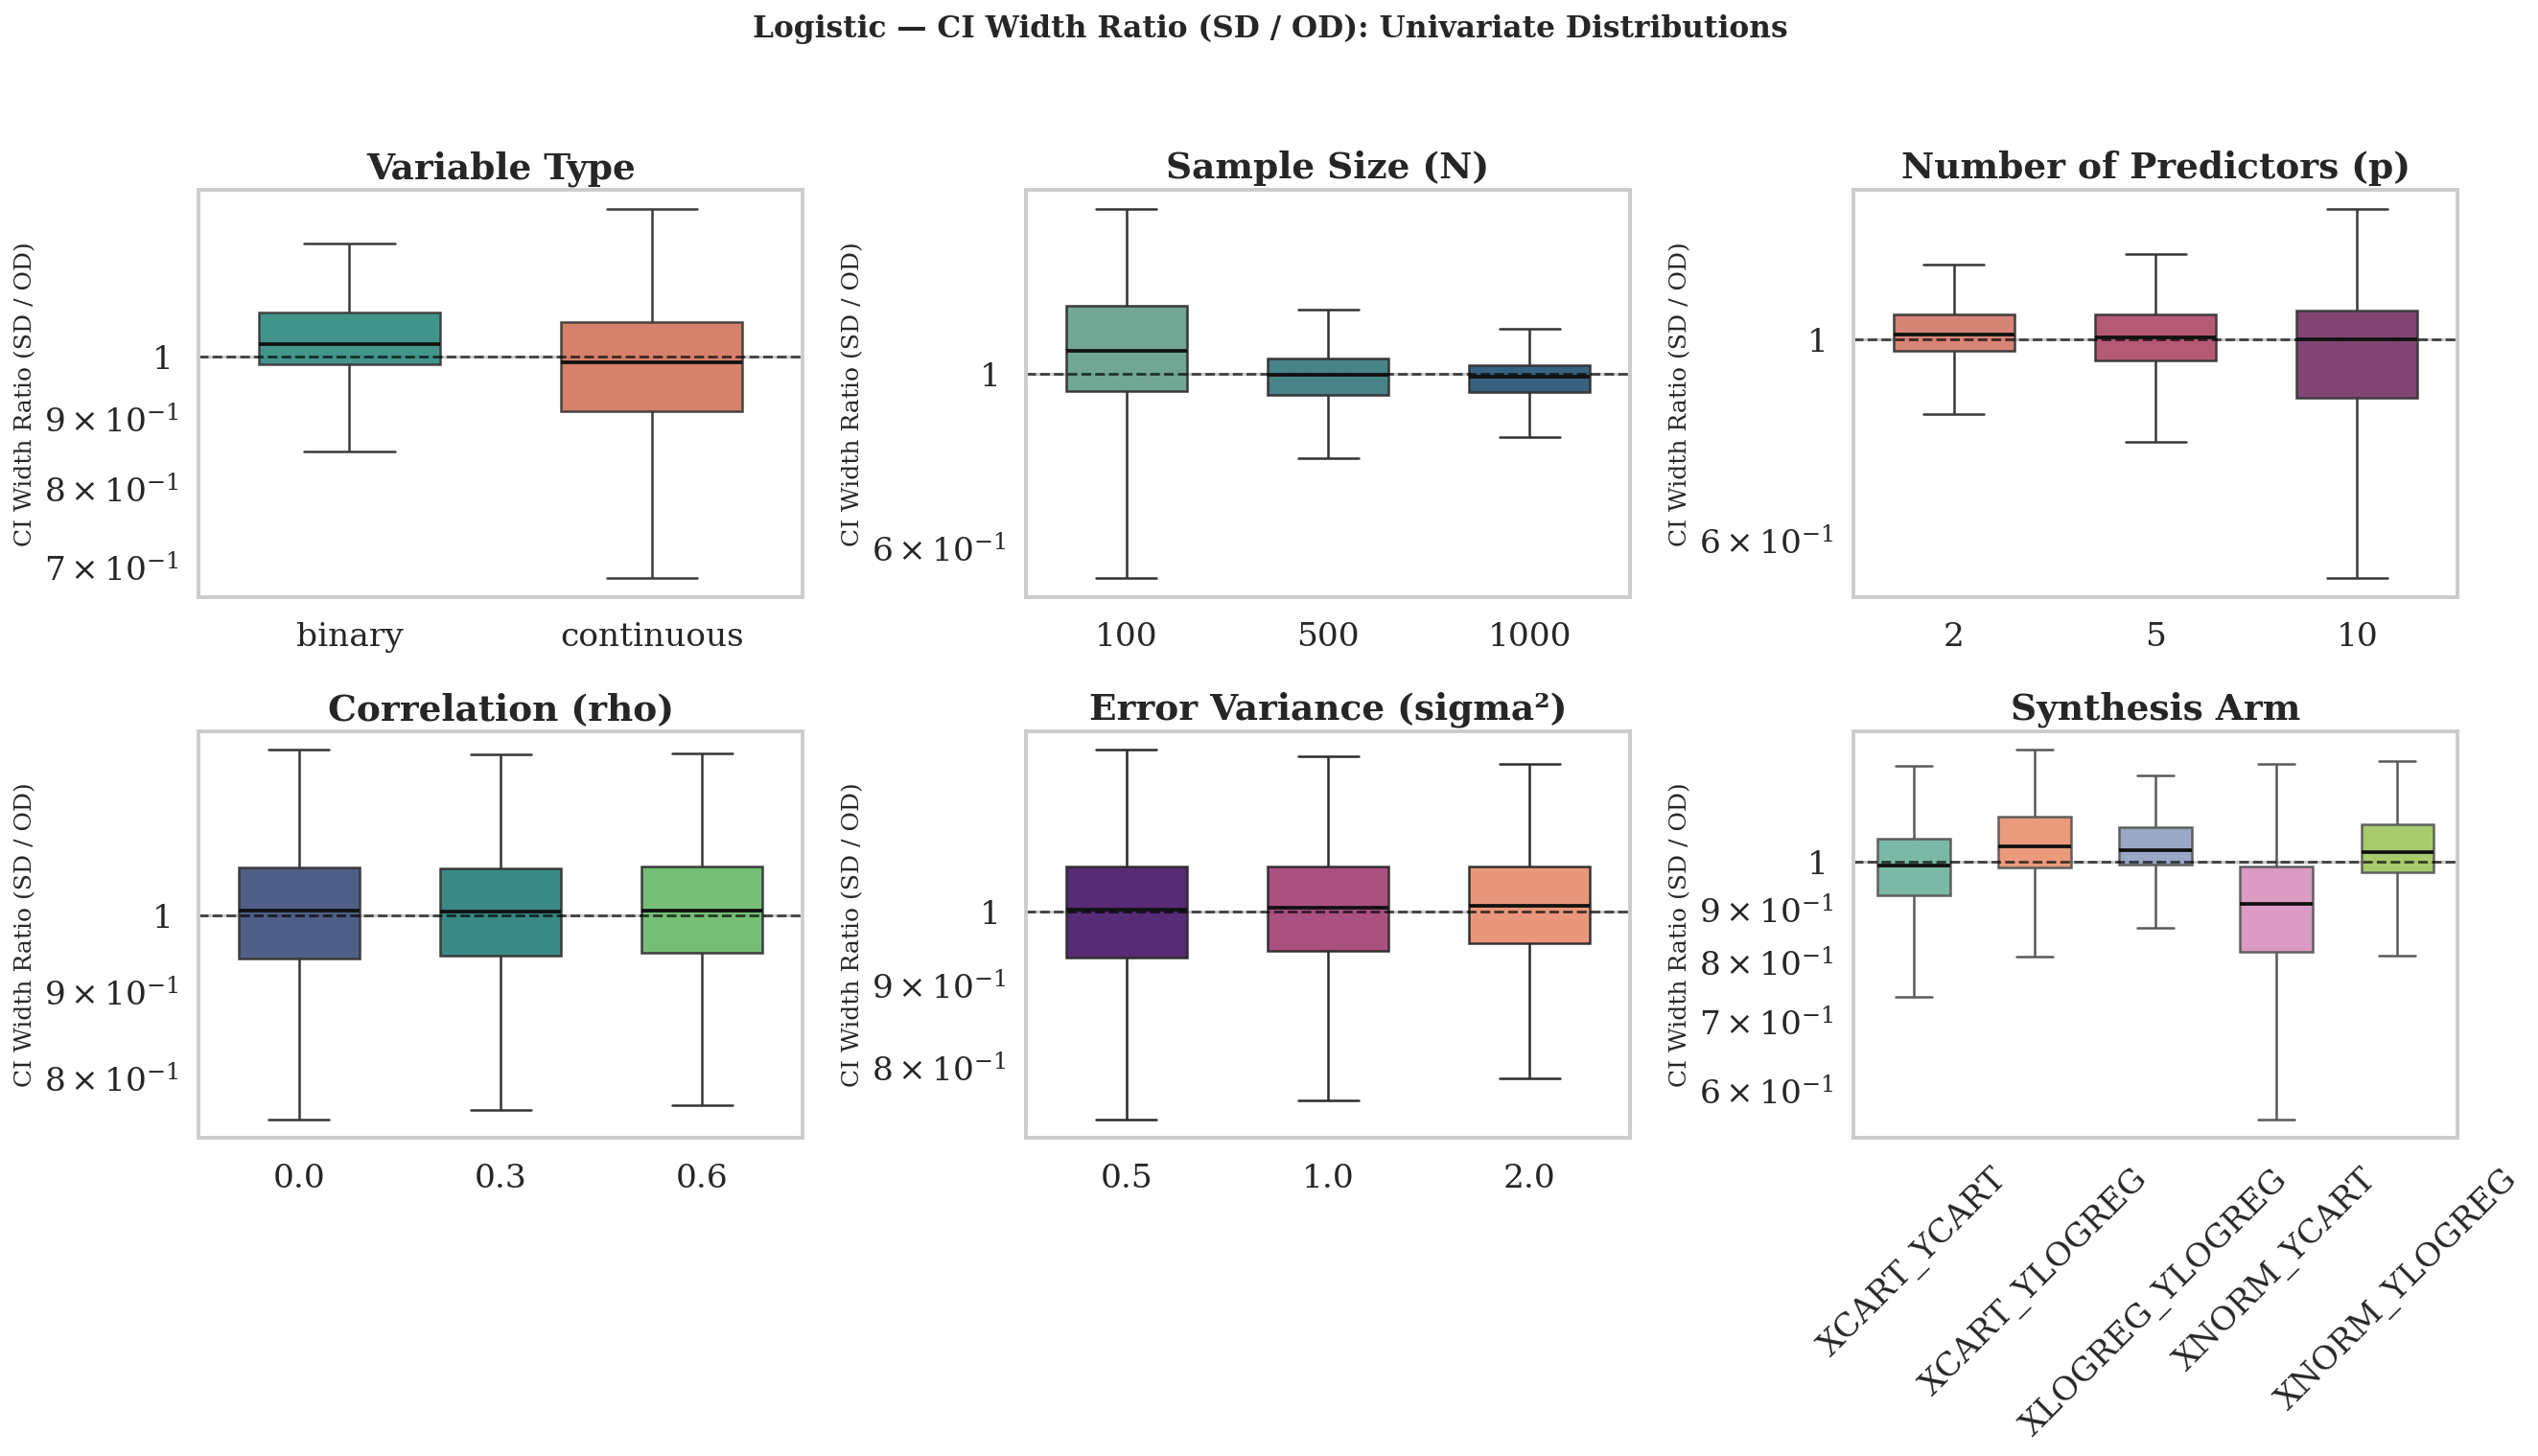

Saved -> ../results/logistic_report_figures/logistic_ci_width_ratio_univariate.png


In [8]:
for metric_col, metric_label, file_stub in METRICS:
    make_univariate_distribution_grid(df, metric_col, metric_label, file_stub)

## Cross-Analysis by Method

The combined synthesis arm is crossed one-to-one with the remaining factors to emphasize where method choice changes the distribution of the selected indicators.

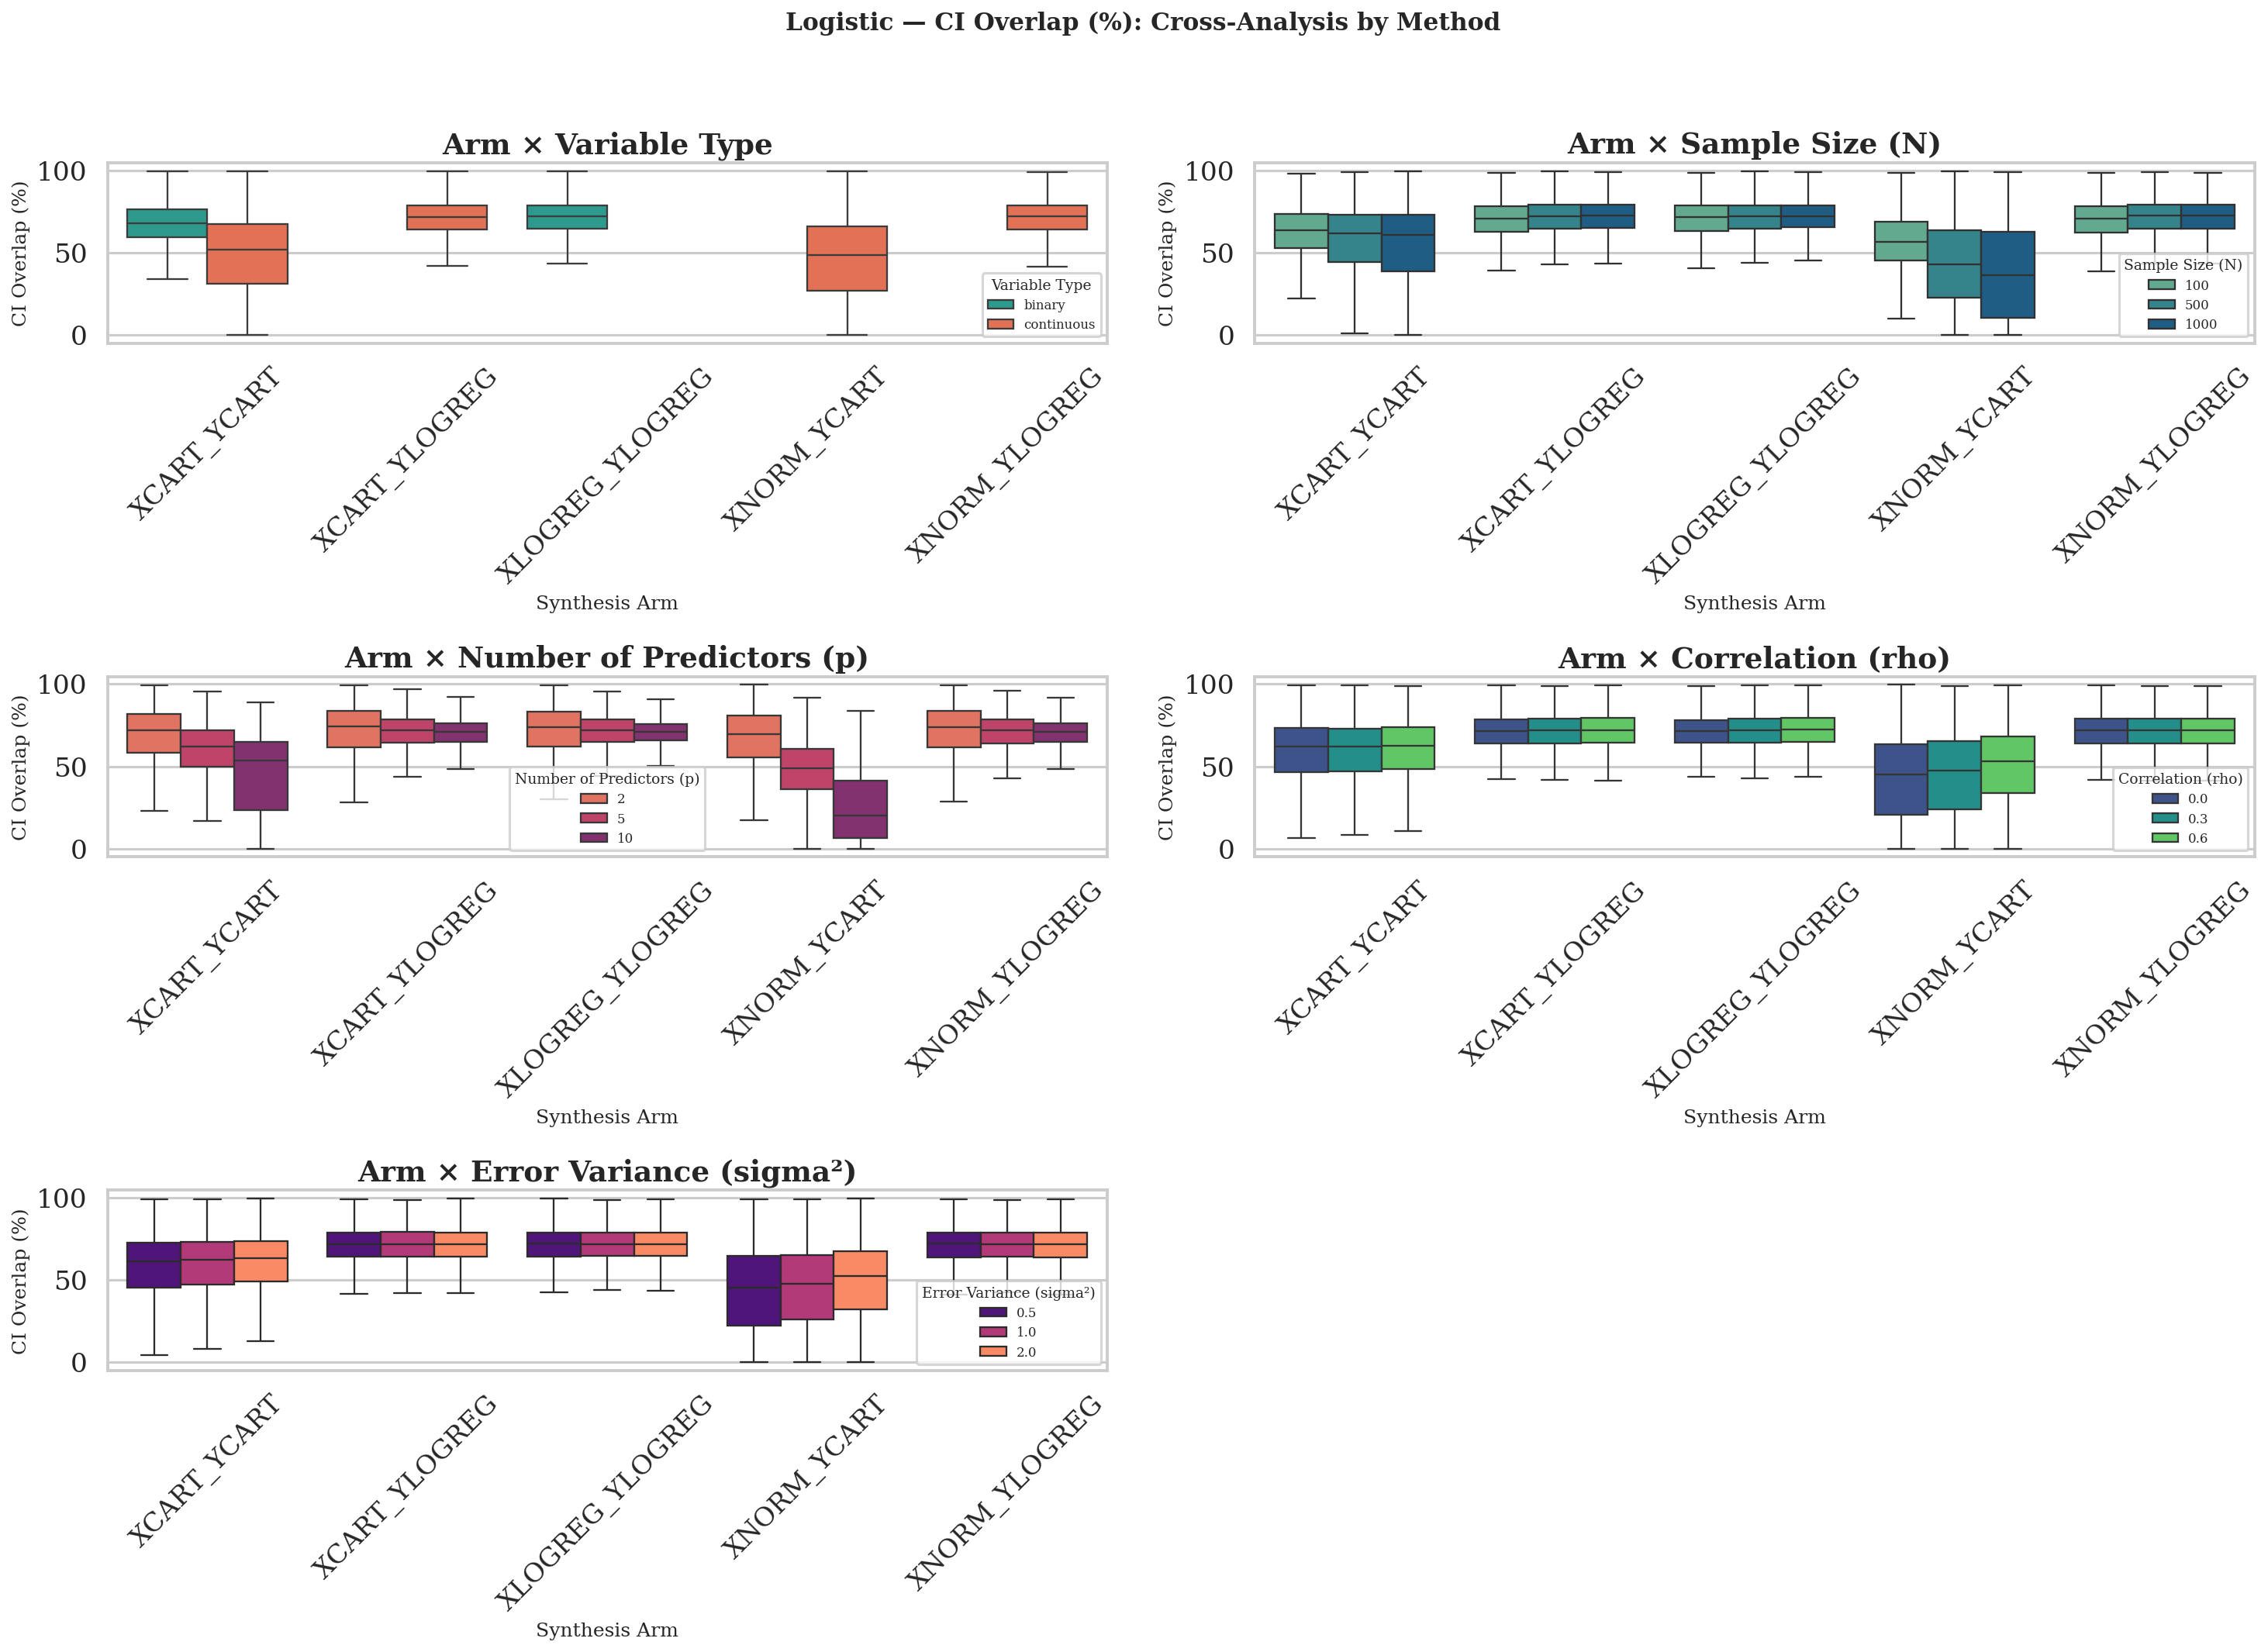

Saved -> ../results/logistic_report_figures/logistic_cio_by_method.png


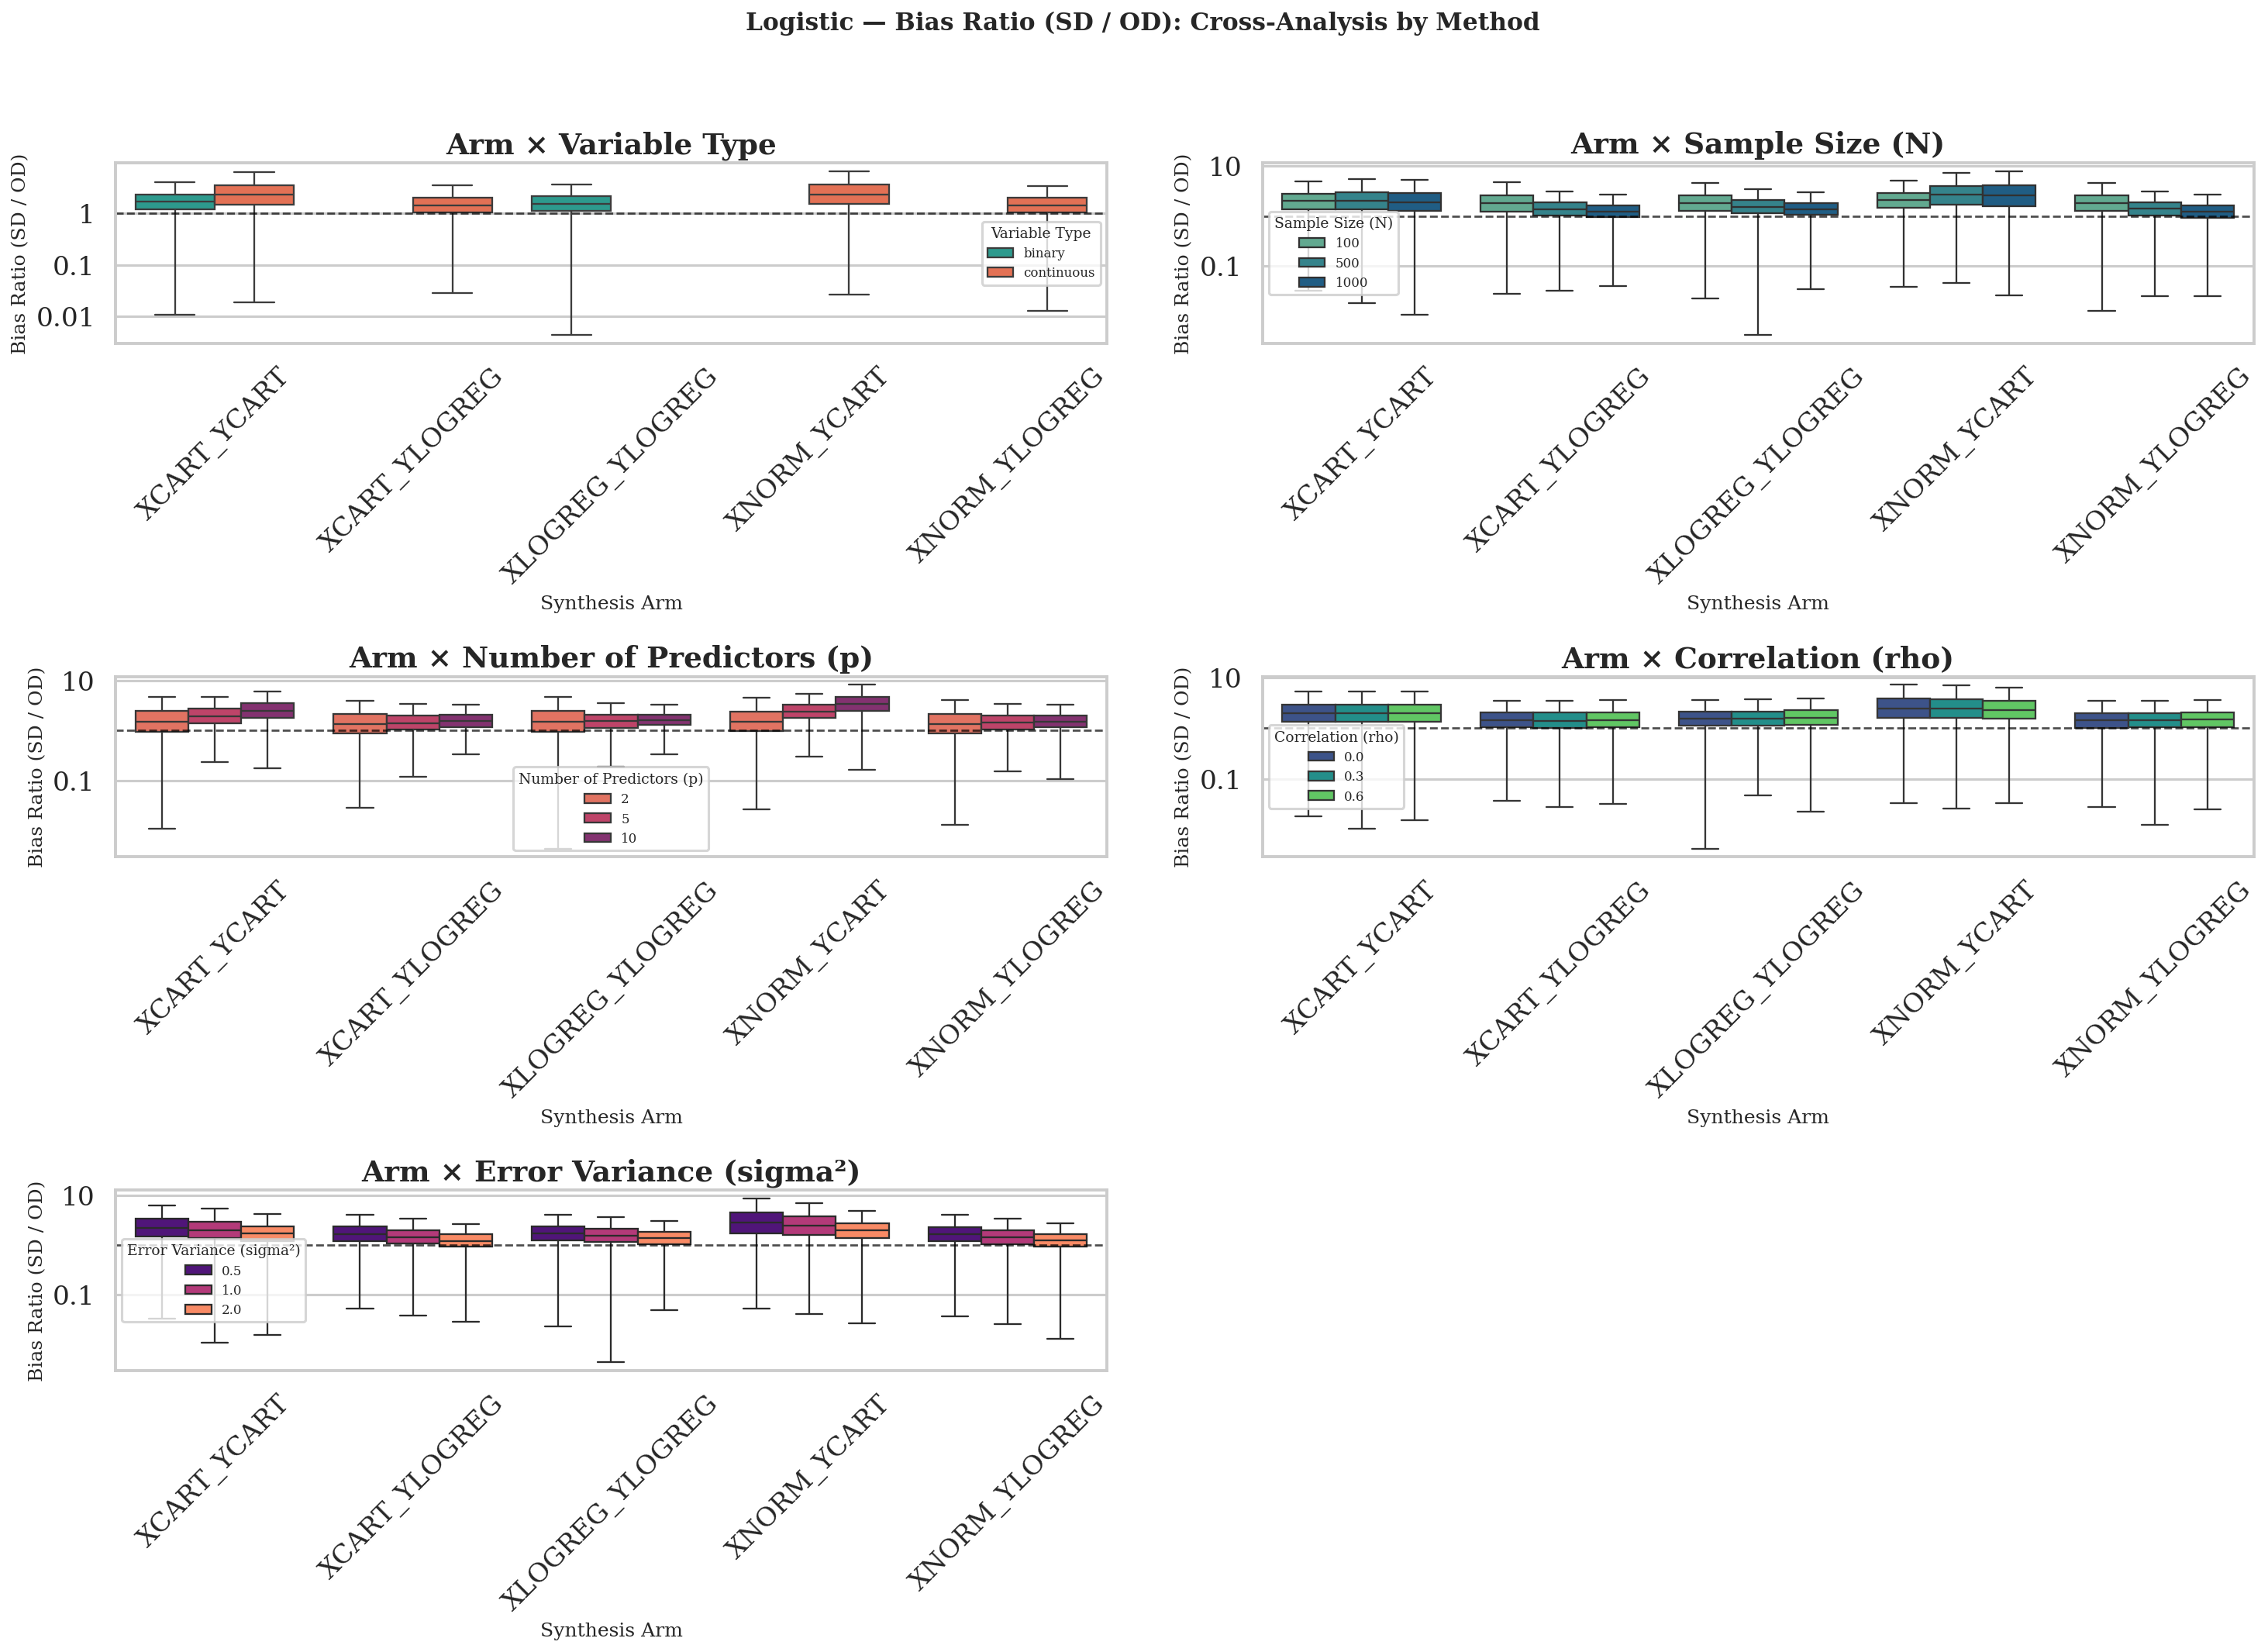

Saved -> ../results/logistic_report_figures/logistic_bias_ratio_by_method.png


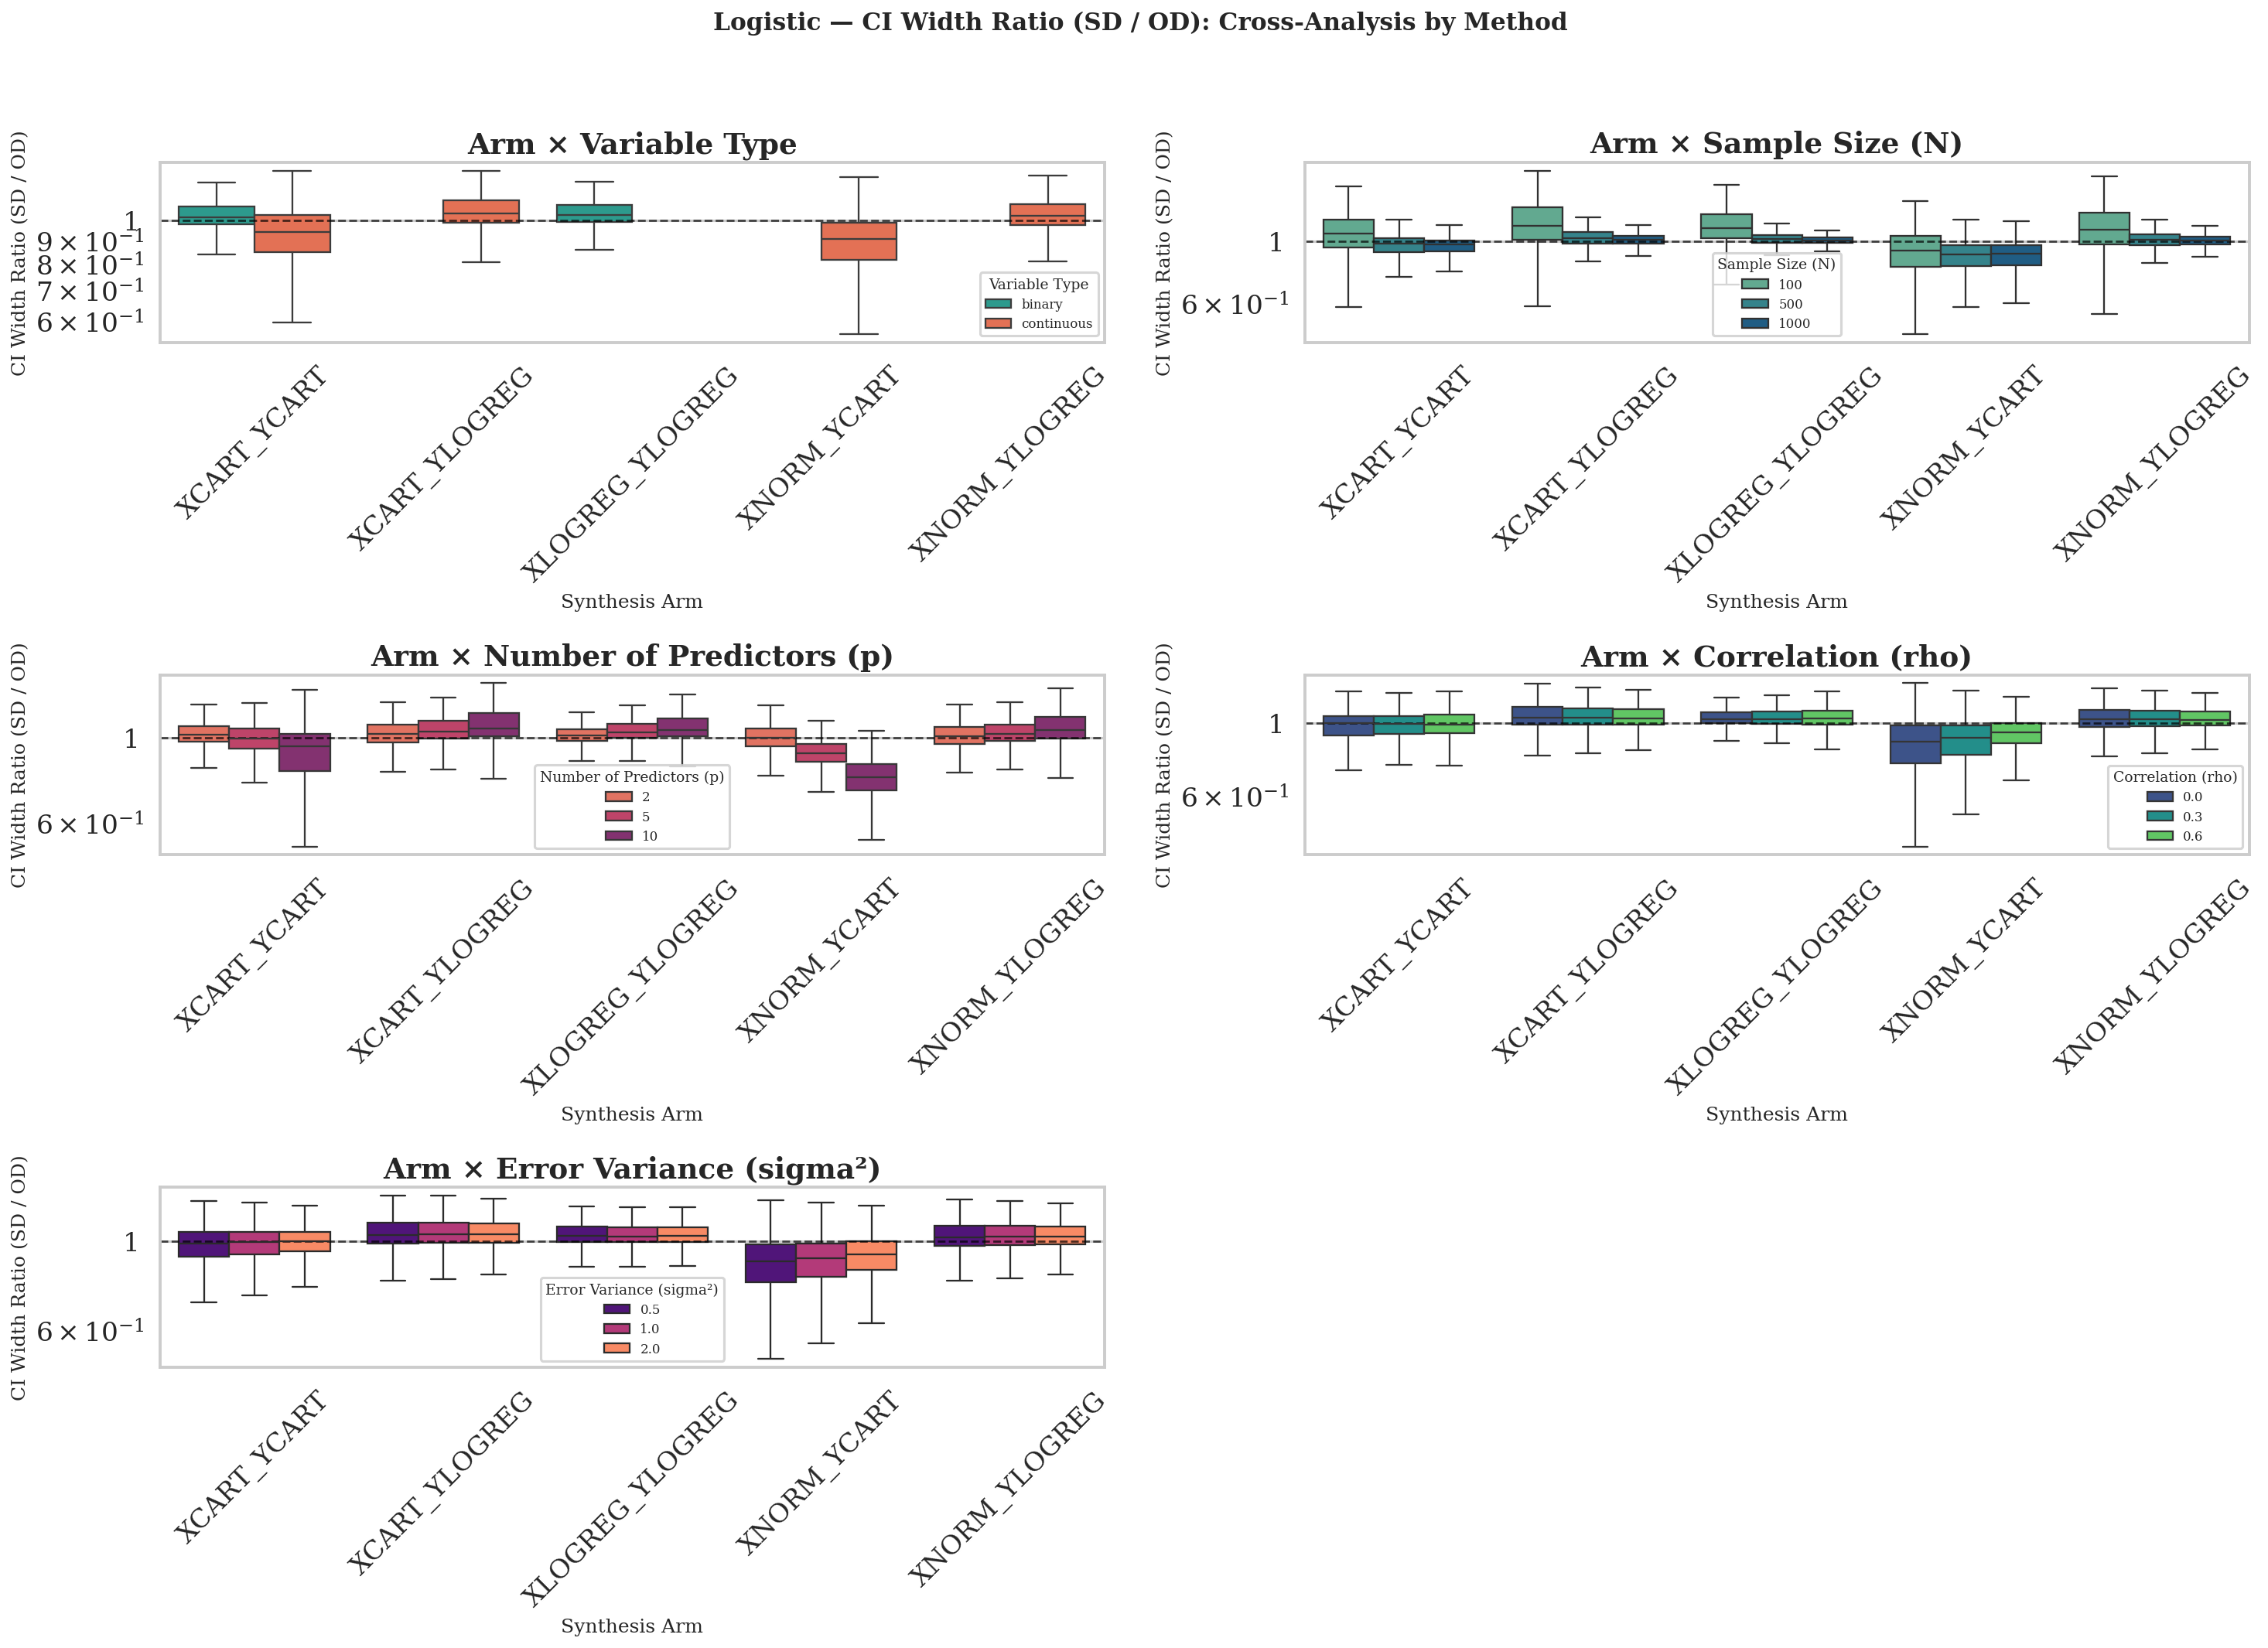

Saved -> ../results/logistic_report_figures/logistic_ci_width_ratio_by_method.png


In [9]:
for metric_col, metric_label, file_stub in METRICS:
    make_method_cross_grid(df, metric_col, metric_label, file_stub)

## Compact Summary

Median and interquartile range for the three main indicators, grouped by variable type and synthesis arm.

In [10]:
summary = (
    df.groupby(["var_type", "arm"])[["ci_overlap_pct", "bias_ratio", "ci_width_ratio"]]
      .agg(["median", lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)])
      .round(3)
)
summary.columns = [
    "cio_median", "cio_q25", "cio_q75",
    "bias_ratio_median", "bias_ratio_q25", "bias_ratio_q75",
    "width_ratio_median", "width_ratio_q25", "width_ratio_q75",
]
display(summary.style
    .format({
        "cio_median": "{:.2f}", "cio_q25": "{:.2f}", "cio_q75": "{:.2f}",
        "bias_ratio_median": "{:.3f}", "bias_ratio_q25": "{:.3f}", "bias_ratio_q75": "{:.3f}",
        "width_ratio_median": "{:.3f}", "width_ratio_q25": "{:.3f}", "width_ratio_q75": "{:.3f}",
    })
    .background_gradient(subset=["cio_median", "cio_q25", "cio_q75"], cmap="YlGn")
    .background_gradient(subset=["bias_ratio_median", "bias_ratio_q25", "bias_ratio_q75"], cmap="YlOrRd_r")
    .background_gradient(subset=["width_ratio_median", "width_ratio_q25", "width_ratio_q75"], cmap="PuBuGn_r")
    .set_caption(f"{TARGET_LABEL} — Compact Summary (median and IQR)")
)
summary

cio_median  cio_q25  cio_q75  bias_ratio_median  \
var_type   arm                                                                
binary     XCART_YCART          67.946   59.481   76.388              1.724   
           XLOGREG_YLOGREG      71.919   64.519   78.727              1.550   
continuous XCART_YCART          51.751   31.378   67.353              2.323   
           XCART_YLOGREG        71.810   64.068   78.898              1.418   
           XNORM_YCART          48.715   26.831   65.931              2.375   
           XNORM_YLOGREG        71.974   63.867   78.783              1.430   

                            bias_ratio_q25  bias_ratio_q75  \
var_type   arm                                               
binary     XCART_YCART               1.217           2.366   
           XLOGREG_YLOGREG           1.139           2.150   
continuous XCART_YCART               1.506           3.504   
           XCART_YLOGREG             1.036           2.026   
           XNORM_YCART               1.561           3.610   
           XNORM_YLOGREG             1.038           2.014   

                            width_ratio_median  width_ratio_q25  \
var_type   arm                                                    
binary     XCART_YCART                   1.016            0.981   
           XLOGREG_YLOGREG               1.028            0.994   
continuous XCART_YCART                   0.944            0.854   
           XCART_YLOGREG                 1.036            0.989   
           XNORM_YCART                   0.910            0.819   
           XNORM_YLOGREG                 1.024            0.977   

                            width_ratio_q75  
var_type   arm                               
binary     XCART_YCART                1.072  
           XLOGREG_YLOGREG            1.082  
continuous XCART_YCART                1.026  
           XCART_YLOGREG              1.107  
           XNORM_YCART                0.990  
           XNORM_YLOGREG              1.088